In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2, multivariate_normal
import torch
from torch.distributions import MultivariateNormal

# PCA and HDR calibration via calculate_PIT
from moc.metrics.distribution_metrics import calculate_PIT, pce

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
from pathlib import Path
import glob

In [ ]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.3f}'.format})

config = get_config()
config.device = 'cuda'

data_group, data_name = 'cevid', 'air'
seed = 42 #choose the seed with which your model was trained on, you can look it up from the checkpoints

rc = RunConfig(config, data_group, data_name, seed = seed)
datamodule = RealDataModule(rc, num_workers=8, seed = seed)
p, q = datamodule.input_dim, datamodule.output_dim

In [19]:
#This is to automatically select checkpoints

def find_latest_ckpt(
    log_root,
    data_group,
    data_name,
    seed,
    lam,
    prerank="none",
):
    parts = [f"model=mixture", f"seed={seed}", f"prerank={prerank}", f"lambda={lam}"]
    exp_dir_name = ",".join(parts)

    pattern = (
        Path(log_root)
        / "*"                 # any date
        / "*"                 # any time
        / data_group
        / data_name
        / exp_dir_name
        / "0"
        / "checkpoints"
        / "epoch_*.ckpt"

    )

    # Expand to full path
    ckpts = list(Path(log_root).glob(pattern.as_posix().replace(str(log_root) + "/", "")))

    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found for pattern: {pattern}")

    ckpts = sorted(ckpts)        # sorts by path, which sorts timestamp folders correctly
    return ckpts[-1]             # latest ckpt from latest date, time, and highest epoch

In [ ]:
# Reliability curves for the same synthetic cases
from moc.metrics.distribution_metrics import pce

alphas = torch.linspace(0, 1, 100).cpu().numpy()

def _mean_cdf_and_pce(cdfs, pces):
    cdf_mean = cdfs.mean(dim=0).cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean

def _plot_reliability(ax, cdf, pce, title=None):
    ax.plot(alphas, cdf, color="0.2", lw=1)
    ax.plot([0, 1], [0, 1], "r--", lw=0.8)
    if title:
        ax.set_title(title, fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([])
    ax.text(0.02, 0.92, f"PCE={pce:.3f}", transform=ax.transAxes, fontsize=7)

fig, axs = plt.subplots(len(preranks), len(cases),
                        figsize=(2.4 * len(cases), 1.8 * len(preranks)),
                        sharex=True, sharey=True)

for j, (name, mu_pred, cov_pred) in enumerate(cases):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N)
    for i, pr in enumerate(preranks):
        pces, cdfs = pce(dist_pred, y, n_samples=100, prerank=pr, setup="real")
        cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
        ax = axs[i, j]
        title = name if i == 0 else None
        _plot_reliability(ax, cdf_mean, pce_mean, title=title)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
log_root = "logs"

ckpt_path = find_latest_ckpt(
    log_root=log_root,
    data_group=data_group,
    data_name=data_name,
    seed=seed,
    lam=0.1,
    prerank="marginal",
    # prerank="combined",
)

print("Using checkpoint:", ckpt_path)

In [14]:
def load_metrics(path):
    df = pd.read_csv(path)
    avg = df.groupby(['data_name'], sort=False).mean(numeric_only=True).reset_index()
    drop_cols = ['seed', 'train_prerank', 'train_time_seconds', 'epochs_trained', 'best_epoch']
    avg = avg.drop(columns=drop_cols, errors='ignore')
    return avg

avg_df_with_density_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=density.csv')
avg_df_with_marginal_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=marginal.csv')
avg_df_with_mean_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=mean.csv')
avg_df_with_variance_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=variance.csv')
avg_df_with_pca_reg = load_metrics('csv-files/metrics-from-model-trained-on-train_prerank=pca.csv')

# Simulations

## Ex 1 : Opposite correlation, same mean

In [2]:
# Synthetic 2D example with opposite correlation, matching marginals
np.random.seed(7)
N = 15_000
rho_gt, rho_pred = 0.8, -0.8

# delta = -0.05                 # small deviation in inclination
# rho_gt = 0.8
# rho_pred = rho_gt + delta

mean = np.zeros(2)
mean_pred = np.array([0.0, 0.0])

# var1 = 1.0
# var2 = 1.6

# cov_gt = np.array([
#     [var1, rho_gt * np.sqrt(var1 * var2)],
#     [rho_gt * np.sqrt(var1 * var2), var2]
# ])

# cov_pred = np.array([
#     [var1, rho_pred * np.sqrt(var1 * var2)],
#     [rho_pred * np.sqrt(var1 * var2), var2]
# ])

# cov_gt = np.array([[var1, rho_gt], [rho_gt, var2]])
# cov_pred = np.array([[var1, rho_pred], [rho_pred, var2]])


# GT = np.random.multivariate_normal(mean, cov_gt, size=N)
# Pred = np.random.multivariate_normal(mean_pred, cov_pred, size=N)

In [3]:
def generate_data(rho, rho_pred):

    np.random.seed(7)
    N = 15_000
    mean = np.zeros(2)
    Sigma_true = np.array([[1.0,  rho],
                            [rho,  1.0]])
    Sigma_hat  = np.array([[1.0, rho_pred],
                            [rho_pred, 1.0]])

    GT = np.random.multivariate_normal(mean, Sigma_true, size=N)
    Pred = np.random.multivariate_normal(mean, Sigma_hat, size=N)

    return GT, Pred, Sigma_true, Sigma_hat

## Ex 2 : Same correlation, same mean and matching marginals

In [ ]:
np.random.seed(7)
N = 15_000
rho_gt, rho_pred = 0.8, 0.8
mean = np.zeros(2)
cov_gt = np.array([[1.0, rho_gt], [rho_gt, 1.0]])
cov_pred = np.array([[1.0, rho_pred], [rho_pred, 1.0]])


GT = np.random.multivariate_normal(mean, cov_gt, size=N)
Pred = np.random.multivariate_normal(mean, cov_pred, size=N)

## Ex 3 : small difference in correlation, same means and matching marginals

In [ ]:
np.random.seed(7)
N = 15_000
rho_gt, rho_pred = 0.8, 0  # correlation between the two dimensions
mean = np.zeros(2)
cov_gt = np.array([[1.0, rho_gt], [rho_gt, 1.0]])
cov_pred = np.array([[1.0, rho_pred], [rho_pred, 1.0]])


GT = np.random.multivariate_normal(mean, cov_gt, size=N)
Pred = np.random.multivariate_normal(mean, cov_pred, size=N)

## Ex 4 : same correlations, different means

In [42]:
np.random.seed(7)
N = 15_000
rho_gt, rho_pred = 0.8, 0.8
mean = np.zeros(2)
mean_pred = np.array([1.0, 0.0])

cov_gt = np.array([[1.0, rho_gt], [rho_gt, 1.0]])
cov_pred = np.array([[1.0, rho_pred], [rho_pred, 1.0]])


GT = np.random.multivariate_normal(mean, cov_gt, size=N)
Pred = np.random.multivariate_normal(mean_pred, cov_pred, size=N)

## Ex 5 : small angle 

In [86]:
def cov_from_angle(theta_deg, lam1=3.0, lam2=0.6):
    """2D covariance with principal variances lam1, lam2 rotated by theta."""
    th = np.deg2rad(theta_deg)
    R = np.array([[np.cos(th), -np.sin(th)],
                  [np.sin(th),  np.cos(th)]])
    D = np.diag([lam1, lam2])
    return R @ D @ R.T

N = 15_000

mean_gt = np.array([0.0, 0.0])
mean_pred = np.array([0.00, 0.00])

theta_gt = 30.0
delta_theta = 20.0     # small angle difference
theta_pred = theta_gt + delta_theta

cov_gt = cov_from_angle(theta_gt, lam1=3.0, lam2=0.6)
cov_pred = cov_from_angle(theta_pred, lam1=3.0, lam2=0.6)  # same eigenvalues, just rotated

GT = np.random.multivariate_normal(mean_gt, cov_gt, size=N)
Pred = np.random.multivariate_normal(mean_pred, cov_pred, size=N)

## Plots

In [8]:
N = 15_000

In [9]:
GT, Pred, cov_true, cov_pred = generate_data(0.8, -0.8)

In [10]:
x_gt, y_gt = GT.T
x_pr, y_pr = Pred.T

mean = np.zeros(2)
mean_pred = np.zeros(2)

# Batch the predicted dist to match GT shape
cov_pred_t = torch.tensor(cov_pred, dtype=torch.float32)
dist_pred_batch = MultivariateNormal(
    loc=torch.tensor(mean_pred, dtype=torch.float32).repeat(N, 1),
    covariance_matrix=cov_pred_t.expand(N, 2, 2)
)
y_t = torch.tensor(GT, dtype=torch.float32)

# Compute PIT and calibration curves
pce_pca, cdfs_pca = pce(dist_pred_batch, y_t, n_samples=300, prerank='pca', setup='real')
pce_hdr, cdfs_hdr = pce(dist_pred_batch, y_t, n_samples=300, prerank='density', setup='real')

alphas = torch.linspace(0, 1, 100).numpy()
pca_curve = cdfs_pca[0].cpu().numpy()
hdr_curve = cdfs_hdr[0].cpu().numpy()

pce_pca_full, cdfs_pca_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='pca', setup='real')
pce_hdr_full, cdfs_hdr_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='density', setup='real')
pce_marg_full, cdfs_marg_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='marginal', setup='real')
# pce_mean_full, cdfs_mean_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='mean', setup='real')
pce_var_full, cdfs_var_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='variance', setup='real')
pce_dep_full, cdfs_dep_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='dependency', setup='real')
# pce_cdf_full, cdfs_cdf_full = pce(dist_pred_batch, y_t, n_samples=300, prerank='cdf', setup='real')

alphas = torch.linspace(0, 1, 100).cpu().numpy()
pca_curve = cdfs_pca_full[0].cpu().numpy()
hdr_curve = cdfs_hdr_full[0].cpu().numpy()
cal_dim1 = cdfs_marg_full[0].cpu().numpy()
cal_dim2 = cdfs_marg_full[1].cpu().numpy()
# mean_curve = cdfs_mean_full[0].cpu().numpy()
var_curve = cdfs_var_full[0].cpu().numpy()
dep_curve = cdfs_dep_full[0].cpu().numpy()
# cdf_curve = cdfs_cdf_full[0].cpu().numpy()

In [35]:
# Global style tweaks (safe for papers)
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


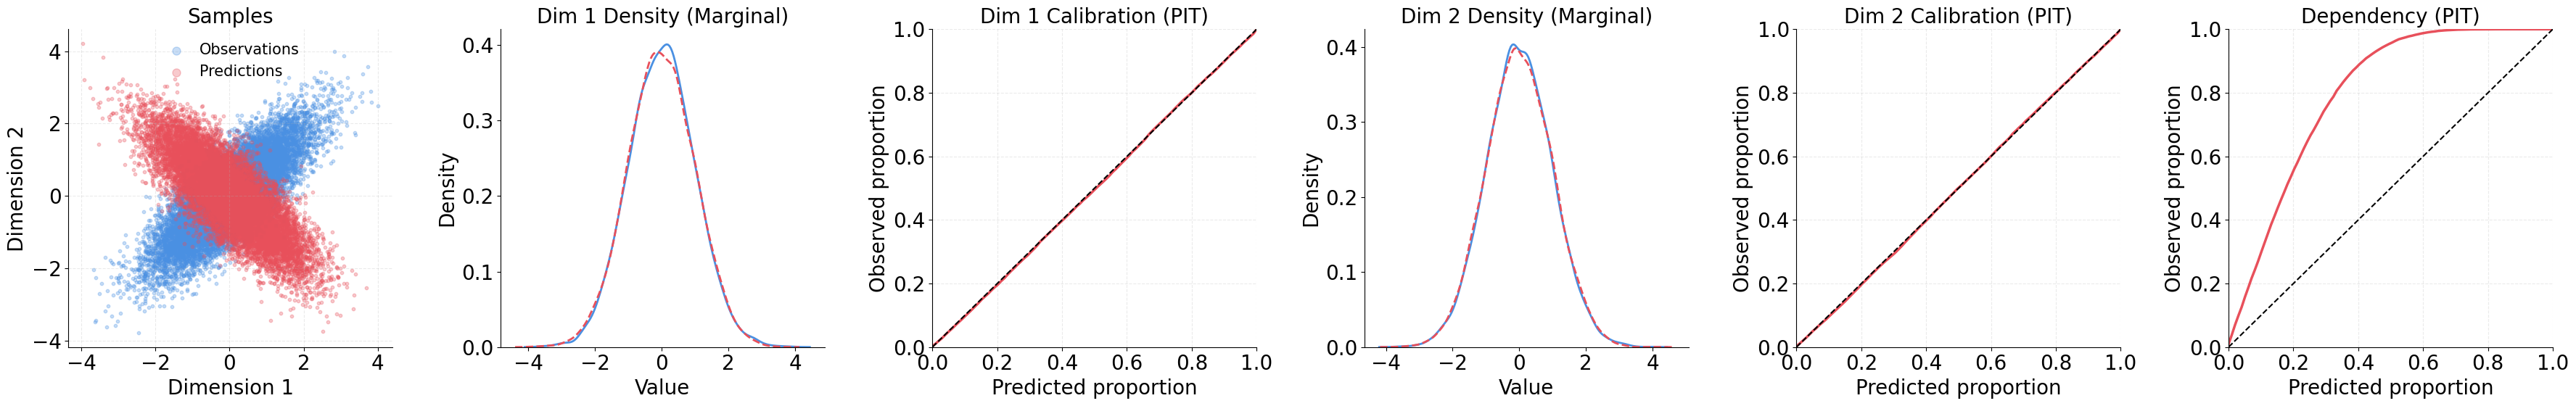

In [ ]:
alphas = torch.linspace(0, 1, 100).cpu().numpy()

fig1, axs1 = plt.subplots(1, 6, figsize=(36, 6))

# -------------------------------------------------
# Samples
# -------------------------------------------------
axs1[0].scatter(GT[:, 0], GT[:, 1], s=10, alpha=0.3,
                label='Observations', color='#4A90E2')
axs1[0].scatter(Pred[:, 0], Pred[:, 1], s=10, alpha=0.3,
                label='Predictions', color='#E8505B')

axs1[0].set_title('Samples')
axs1[0].set_xlabel('Dimension 1')
axs1[0].set_ylabel('Dimension 2')
axs1[0].legend(
    frameon=False,
    markerscale=2.5,
    handletextpad=0.5
)
axs1[0].grid(alpha=0.25, linestyle='--')

# -------------------------------------------------
# Dim 1 density
# -------------------------------------------------
sns.kdeplot(x=GT[:, 0], ax=axs1[1],
            label='Obs', color='#4A90E2', linewidth=2)
sns.kdeplot(x=Pred[:, 0], ax=axs1[1],
            label='Pred', color='#E8505B',
            linestyle='--', linewidth=2)

axs1[1].set_title('Dim 1 Density (Marginal)')
axs1[1].set_xlabel('Value')
axs1[1].set_ylabel('Density')
# axs1[1].legend(frameon=False)

# -------------------------------------------------
# Dim 1 calibration
# -------------------------------------------------
axs1[2].plot(alphas, cal_dim1, color='#E8505B', lw=2.5,
             label='Observed')
axs1[2].plot([0, 1], [0, 1], 'k--', lw=1.5)

axs1[2].set_title('Dim 1 Calibration (PIT)')
axs1[2].set_xlabel('Predicted proportion')
axs1[2].set_ylabel('Observed proportion')
axs1[2].set_xlim(0, 1)
axs1[2].set_ylim(0, 1)
axs1[2].grid(alpha=0.25, linestyle='--')

# -------------------------------------------------
# Dim 2 density
# -------------------------------------------------
sns.kdeplot(x=GT[:, 1], ax=axs1[3],
            label='Obs', color='#4A90E2', linewidth=2)
sns.kdeplot(x=Pred[:, 1], ax=axs1[3],
            label='Pred', color='#E8505B',
            linestyle='--', linewidth=2)

axs1[3].set_title('Dim 2 Density (Marginal)')
axs1[3].set_xlabel('Value')
axs1[3].set_ylabel('Density')
# axs1[3].legend(frameon=False)

# -------------------------------------------------
# Dim 2 calibration
# -------------------------------------------------
axs1[4].plot(alphas, cal_dim2, color='#E8505B', lw=2.5)
axs1[4].plot([0, 1], [0, 1], 'k--', lw=1.5)

axs1[4].set_title('Dim 2 Calibration (PIT)')
axs1[4].set_xlabel('Predicted proportion')
axs1[4].set_ylabel('Observed proportion')
axs1[4].set_xlim(0, 1)
axs1[4].set_ylim(0, 1)
axs1[4].grid(alpha=0.25, linestyle='--')

# # -------------------------------------------------
# # Mean calibration
# # -------------------------------------------------
# axs1[5].plot(alphas, mean_curve, color='#E8505B', lw=2.5)
# axs1[5].plot([0, 1], [0, 1], 'k--', lw=1.5)

# axs1[5].set_title('Mean Calibration (PIT)')
# axs1[5].set_xlabel('Predicted proportion')
# axs1[5].set_ylabel('Observed proportion')
# axs1[5].set_xlim(0, 1)
# axs1[5].set_ylim(0, 1)
# axs1[5].grid(alpha=0.25, linestyle='--')


# -------------------------------------------------
# Dependency calibration
# -------------------------------------------------
axs1[5].plot(alphas, dep_curve, color='#E8505B', lw=2.5)
axs1[5].plot([0, 1], [0, 1], 'k--', lw=1.5)

axs1[5].set_title('Dependency (PIT)')
axs1[5].set_xlabel('Predicted proportion')
axs1[5].set_ylabel('Observed proportion')
axs1[5].set_xlim(0, 1)
axs1[5].set_ylim(0, 1)
axs1[5].grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('joint_miscalibration_example.pdf', dpi=300, bbox_inches='tight')
plt.show()

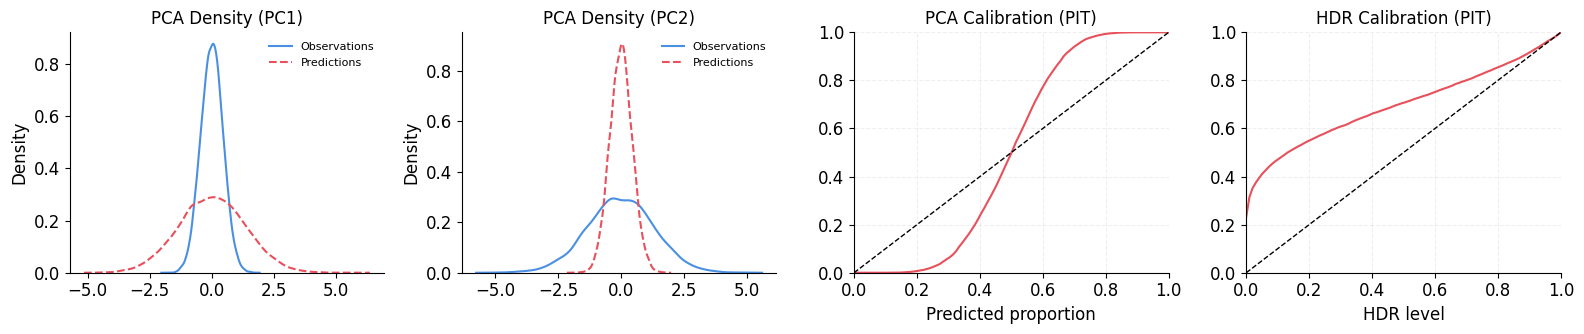

In [36]:
# Second figure: PCA density, PCA calibration, HDR calibration
fig2, axs2 = plt.subplots(1, 4, figsize=(16, 3.5))

pred_pc1_vec = torch.linalg.eigh(torch.tensor(cov_pred, dtype=torch.float32))[1][:, -1].cpu().numpy()
pred_pc2_vec = torch.linalg.eigh(torch.tensor(cov_pred, dtype=torch.float32))[1][:, -2].cpu().numpy()

sns.kdeplot(x=GT @ pred_pc1_vec, ax=axs2[0], label='Observations', color='#4A90E2')
sns.kdeplot(x=Pred @ pred_pc1_vec, ax=axs2[0], label='Predictions', color='#E8505B', linestyle='--')
axs2[0].set_title('PCA Density (PC1)'); axs2[0].legend(frameon=False, fontsize=8)

sns.kdeplot(x=GT @ pred_pc2_vec, ax=axs2[1], label='Observations', color='#4A90E2')
sns.kdeplot(x=Pred @ pred_pc2_vec, ax=axs2[1], label='Predictions', color='#E8505B', linestyle='--')
axs2[1].set_title('PCA Density (PC2)'); axs2[1].legend(frameon=False, fontsize=8)

axs2[2].plot(alphas, pca_curve, label='Observed', color='#E8505B')
axs2[2].plot([0, 1], [0, 1], 'k--', lw=1)
axs2[2].set_title('PCA Calibration (PIT)')
axs2[2].set_xlabel('Predicted proportion'); axs2[2].set_xlim(0, 1); axs2[2].set_ylim(0, 1)
axs2[2].grid(alpha=0.2, linestyle='--')

axs2[3].plot(alphas, hdr_curve, color='#E8505B', label='Observed')
axs2[3].plot([0, 1], [0, 1], 'k--', lw=1)
axs2[3].set_title('HDR Calibration (PIT)')
axs2[3].set_xlabel('HDR level'); axs2[3].set_xlim(0, 1); axs2[3].set_ylim(0, 1)
axs2[3].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('joint_miscalibration_example2.pdf', dpi=300, bbox_inches='tight')
plt.show()

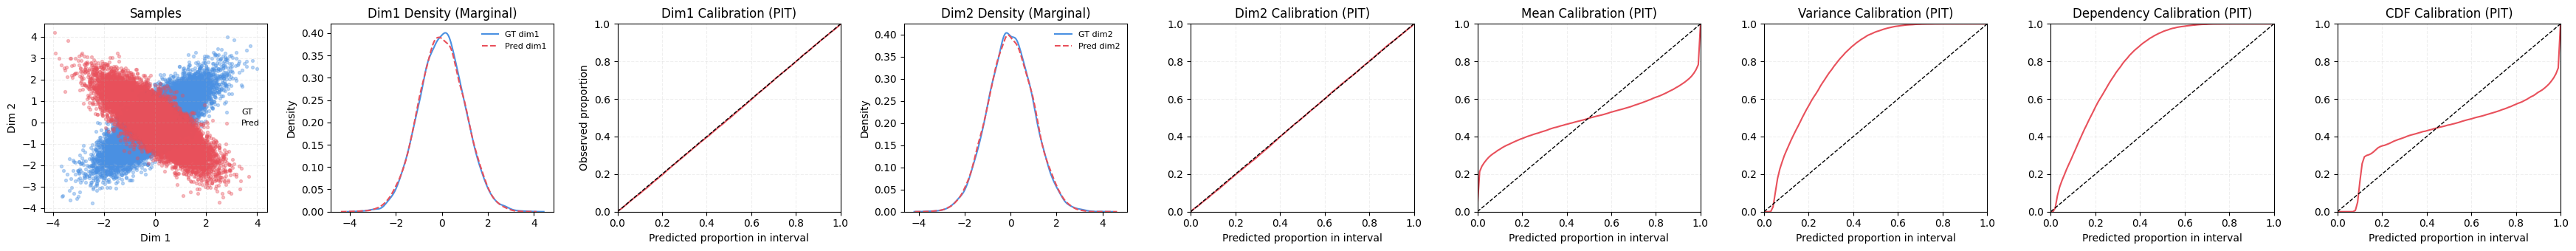

In [ ]:
alphas = torch.linspace(0, 1, 100).cpu().numpy()

fig1, axs1 = plt.subplots(1, 9, figsize=(35, 3.5))

# Samples
axs1[0].scatter(GT[:, 0], GT[:, 1], s=8, alpha=0.35, label='GT', color='#4A90E2')
axs1[0].scatter(Pred[:, 0], Pred[:, 1], s=8, alpha=0.35, label='Pred', color='#E8505B')
axs1[0].set_title('Samples'); axs1[0].set_xlabel('Dim 1'); axs1[0].set_ylabel('Dim 2')
axs1[0].legend(frameon=False, fontsize=8); axs1[0].grid(alpha=0.2, linestyle='--')

# Dim1 density
sns.kdeplot(x=GT[:,0], ax=axs1[1], label='GT dim1', color='#4A90E2')
sns.kdeplot(x=Pred[:,0], ax=axs1[1], label='Pred dim1', color='#E8505B', linestyle='--')
axs1[1].set_title('Dim1 Density (Marginal)'); axs1[1].legend(frameon=False, fontsize=8)

# Dim1 calibration
axs1[2].plot(alphas, cal_dim1, label='Observed', color='#E8505B')
axs1[2].plot([0, 1], [0, 1], 'k--', lw=1)
axs1[2].set_title('Dim1 Calibration (PIT)')
axs1[2].set_xlabel('Predicted proportion in interval'); axs1[2].set_ylabel('Observed proportion')
axs1[2].set_xlim(0, 1); axs1[2].set_ylim(0, 1); axs1[2].grid(alpha=0.2, linestyle='--')

# Dim2 density
sns.kdeplot(x=GT[:,1], ax=axs1[3], label='GT dim2', color='#4A90E2')
sns.kdeplot(x=Pred[:,1], ax=axs1[3], label='Pred dim2', color='#E8505B', linestyle='--')
axs1[3].set_title('Dim2 Density (Marginal)'); axs1[3].legend(frameon=False, fontsize=8)

# Dim2 calibration
axs1[4].plot(alphas, cal_dim2, label='Observed', color='#E8505B')
axs1[4].plot([0, 1], [0, 1], 'k--', lw=1)
axs1[4].set_title('Dim2 Calibration (PIT)')
axs1[4].set_xlabel('Predicted proportion in interval'); axs1[4].set_xlim(0, 1); axs1[4].set_ylim(0, 1)
axs1[4].grid(alpha=0.2, linestyle='--')

# # Mean calibration
# axs1[5].plot(alphas, mean_curve, label='Observed', color='#E8505B')
# axs1[5].plot([0, 1], [0, 1], 'k--', lw=1)
# axs1[5].set_title('Mean Calibration (PIT)')
# axs1[5].set_xlabel('Predicted proportion in interval'); axs1[5].set_xlim(0, 1); axs1[5].set_ylim(0, 1)
# axs1[5].grid(alpha=0.2, linestyle='--')

# Variance calibration
axs1[6].plot(alphas, var_curve, label='Observed', color='#E8505B')
axs1[6].plot([0, 1], [0, 1], 'k--', lw=1)
axs1[6].set_title('Variance Calibration (PIT)')
axs1[6].set_xlabel('Predicted proportion in interval'); axs1[6].set_xlim(0, 1); axs1[6].set_ylim(0, 1)
axs1[6].grid(alpha=0.2, linestyle='--')

# Dependency calibration
axs1[7].plot(alphas, dep_curve, label='Observed', color='#E8505B')
axs1[7].plot([0, 1], [0, 1], 'k--', lw=1)
axs1[7].set_title('Dependency Calibration (PIT)')
axs1[7].set_xlabel('Predicted proportion in interval'); axs1[7].set_xlim(0, 1); axs1[7].set_ylim(0, 1)
axs1[7].grid(alpha=0.2, linestyle='--')

# CDF calibration
axs1[8].plot(alphas, cdf_curve, label='Observed', color='#E8505B')
axs1[8].plot([0, 1], [0, 1], 'k--', lw=1)
axs1[8].set_title('CDF Calibration (PIT)')
axs1[8].set_xlabel('Predicted proportion in interval'); axs1[8].set_xlim(0, 1); axs1[8].set_ylim(0, 1)
axs1[8].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

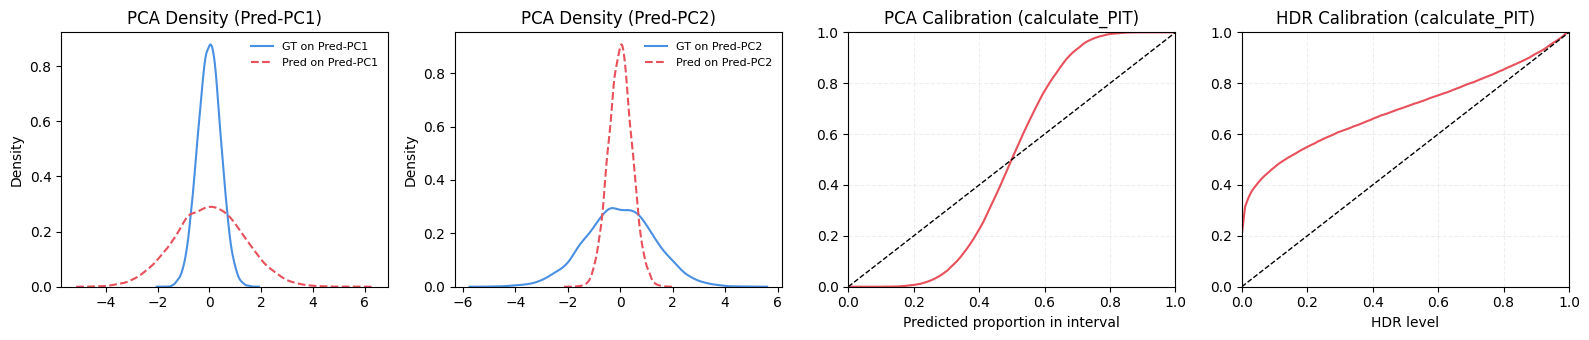

In [10]:
# Second figure: PCA density, PCA calibration, HDR calibration
fig2, axs2 = plt.subplots(1, 4, figsize=(16, 3.5))

pred_pc1_vec = torch.linalg.eigh(torch.tensor(cov_pred, dtype=torch.float32))[1][:, -1].cpu().numpy()
pred_pc2_vec = torch.linalg.eigh(torch.tensor(cov_pred, dtype=torch.float32))[1][:, -2].cpu().numpy()

sns.kdeplot(x=GT @ pred_pc1_vec, ax=axs2[0], label='GT on Pred-PC1', color='#4A90E2')
sns.kdeplot(x=Pred @ pred_pc1_vec, ax=axs2[0], label='Pred on Pred-PC1', color='#E8505B', linestyle='--')
axs2[0].set_title('PCA Density (Pred-PC1)'); axs2[0].legend(frameon=False, fontsize=8)

sns.kdeplot(x=GT @ pred_pc2_vec, ax=axs2[1], label='GT on Pred-PC2', color='#4A90E2')
sns.kdeplot(x=Pred @ pred_pc2_vec, ax=axs2[1], label='Pred on Pred-PC2', color='#E8505B', linestyle='--')
axs2[1].set_title('PCA Density (Pred-PC2)'); axs2[1].legend(frameon=False, fontsize=8)

axs2[2].plot(alphas, pca_curve, label='Observed', color='#E8505B')
axs2[2].plot([0, 1], [0, 1], 'k--', lw=1)
axs2[2].set_title('PCA Calibration (calculate_PIT)')
axs2[2].set_xlabel('Predicted proportion in interval'); axs2[2].set_xlim(0, 1); axs2[2].set_ylim(0, 1)
axs2[2].grid(alpha=0.2, linestyle='--')

axs2[3].plot(alphas, hdr_curve, color='#E8505B', label='Observed')
axs2[3].plot([0, 1], [0, 1], 'k--', lw=1)
axs2[3].set_title('HDR Calibration (calculate_PIT)')
axs2[3].set_xlabel('HDR level'); axs2[3].set_xlim(0, 1); axs2[3].set_ylim(0, 1)
axs2[3].grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

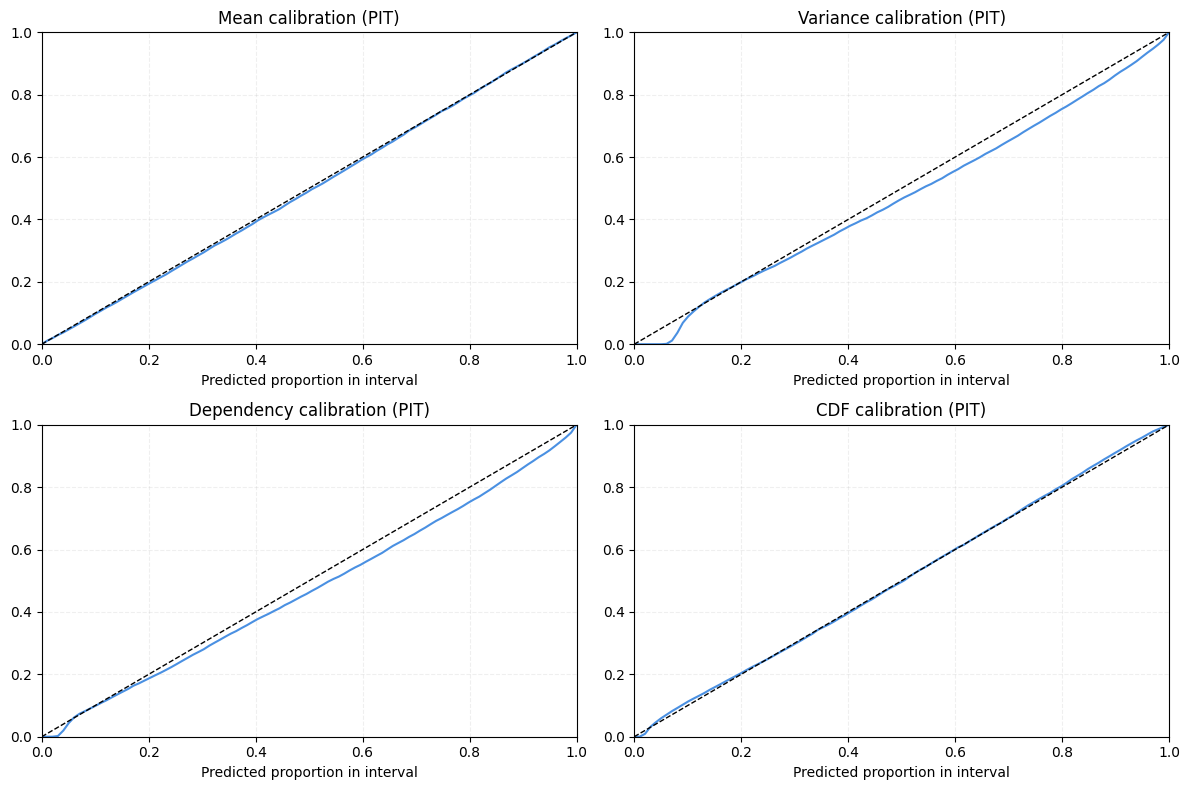

In [90]:
# Reliability plots for rho in ['mean', 'variance', 'dependency'] and rho='cdf'
pce_mean, cdfs_mean = pce(dist_pred_batch, y_t, n_samples=300, prerank='mean', setup='real')
pce_var, cdfs_var = pce(dist_pred_batch, y_t, n_samples=300, prerank='variance', setup='real')
pce_dep, cdfs_dep = pce(dist_pred_batch, y_t, n_samples=300, prerank='dependency', setup='real')
pce_cdf, cdfs_cdf = pce(dist_pred_batch, y_t, n_samples=300, prerank='cdf', setup='real')

curve_mean = cdfs_mean[0].cpu().numpy()
curve_var = cdfs_var[0].cpu().numpy()
curve_dep = cdfs_dep[0].cpu().numpy()
curve_cdf = cdfs_cdf[0].cpu().numpy()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plots = [
    (curve_mean, 'Mean calibration (PIT)', axs[0,0]),
    (curve_var, 'Variance calibration (PIT)', axs[0,1]),
    (curve_dep, 'Dependency calibration (PIT)', axs[1,0]),
    (curve_cdf, 'CDF calibration (PIT)', axs[1,1]),
]
for curve, title, ax in plots:
    ax.plot(alphas, curve, color='#4A90E2', label='Observed')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted proportion in interval')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

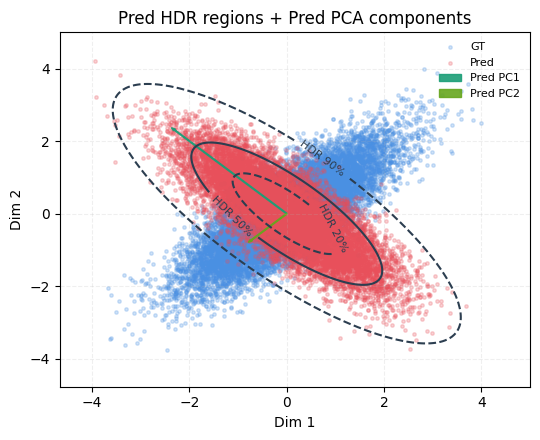

In [ ]:
# Plot GT/Pred with Pred HDR regions and Pred PCA components
levels = [0.2, 0.5, 0.9]

# Grid for density contours
x_min, x_max = GT[:, 0].min() - 1.0, GT[:, 0].max() + 1.0
y_min, y_max = GT[:, 1].min() - 1.0, GT[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
positions = np.dstack((xx, yy))

mvn_pred = multivariate_normal(mean=mean, cov=cov_pred)
zz = mvn_pred.pdf(positions)

# Density thresholds corresponding to HDR levels
thr = []
for a in levels:
    r2 = chi2.ppf(a, df=2)
    pt = mean + np.array([np.sqrt(r2), 0.0])
    thr.append(mvn_pred.pdf(pt))

# PCA components of predictive distribution
vals_pred, vecs_pred = np.linalg.eigh(cov_pred)
order = np.argsort(vals_pred)[::-1]
vals_pred, vecs_pred = vals_pred[order], vecs_pred[:, order]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 4.5))
ax.scatter(GT[:, 0], GT[:, 1], s=6, alpha=0.25, label='GT', color='#4A90E2')
ax.scatter(Pred[:, 0], Pred[:, 1], s=6, alpha=0.25, label='Pred', color='#E8505B')

# HDR contours (Pred)
cont = ax.contour(xx, yy, zz, levels=sorted(thr), colors=['#2c3e50', '#2c3e50'], linestyles=['--', '-'])
ax.clabel(cont, fmt={thr[0]: 'HDR 20%',thr[1]: 'HDR 50%', thr[2]: 'HDR 90%'}, fontsize=8)

# PCA axes (Pred)
scale = 2.5 * np.sqrt(vals_pred)
origin = mean
for i in range(2):
    vec = vecs_pred[:, i] * scale[i]
    ax.arrow(*origin, *vec, color='#1B9E77' if i == 0 else '#66A61E', width=0.02,
             length_includes_head=True, alpha=0.9, label=f'Pred PC{i+1}')

ax.set_title('Pred HDR regions + Pred PCA components')
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
ax.legend(frameon=False, fontsize=8, loc='upper right')
ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

# Simulations for paper

Each case below uses a simple 2D Gaussian forecast and evaluates calibration for all preranks using `pce`. Low PCE means closer to Uniform PIT (better calibrated for that prerank).

In [2]:
# Small, focused calibration examples for each prerank
np.random.seed(123)
torch.manual_seed(123)

N = 5000
preranks = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']


def make_batch_mvn(mean, cov, N):
    mean_t = torch.tensor(mean, dtype=torch.float32)
    cov_t = torch.tensor(cov, dtype=torch.float32)
    return MultivariateNormal(
        loc=mean_t.repeat(N, 1),
        covariance_matrix=cov_t.expand(N, 2, 2)
    )


def eval_case(name, mean_gt, cov_gt, mean_pred, cov_pred, n_samples=200):
    GT = np.random.multivariate_normal(mean_gt, cov_gt, size=N)
    y_t = torch.tensor(GT, dtype=torch.float32)
    dist_pred_batch = make_batch_mvn(mean_pred, cov_pred, N)

    pce_scores = {}
    for pr in preranks:
        pce_vals, _ = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        pce_scores[pr] = float(pce_vals.mean())

    print(f"\n{name}")
    for pr, score in pce_scores.items():
        print(f"  {pr:10s}  PCE={score:0.4f}")


# Case A: Wrong correlation, same marginals (dependency should fail)
mean_gt = np.array([0.0, 0.0])
mean_pred = np.array([0.0, 0.0])
var1, var2 = 1.0, 1.0
rho_gt, rho_pred = 0.8, -0.8
cov_gt = np.array([[var1, rho_gt], [rho_gt, var2]])
cov_pred = np.array([[var1, rho_pred], [rho_pred, var2]])

eval_case("Case A: wrong correlation (same marginals)", mean_gt, cov_gt, mean_pred, cov_pred)


# Case B: Mean bias (mean should fail, marginals often also fail)
mean_gt = np.array([0.0, 0.0])
mean_pred = np.array([1.0, 0.0])
cov_gt = np.eye(2)
cov_pred = np.eye(2)

eval_case("Case B: mean shift", mean_gt, cov_gt, mean_pred, cov_pred)


# Case C: Underdispersed forecast (variance should fail)
mean_gt = np.array([0.0, 0.0])
mean_pred = np.array([0.0, 0.0])
cov_gt = np.eye(2)
cov_pred = 0.25 * np.eye(2)

eval_case("Case C: underdispersed", mean_gt, cov_gt, mean_pred, cov_pred)


# Case D: Rotated ellipse (PCA should be sensitive)
mean_gt = np.array([0.0, 0.0])
mean_pred = np.array([0.0, 0.0])

def cov_from_angle(theta_deg, lam1=3.0, lam2=0.6):
    th = np.deg2rad(theta_deg)
    R = np.array([[np.cos(th), -np.sin(th)],
                  [np.sin(th),  np.cos(th)]])
    D = np.diag([lam1, lam2])
    return R @ D @ R.T

cov_gt = cov_from_angle(20.0)
cov_pred = cov_from_angle(60.0)

eval_case("Case D: rotated covariance", mean_gt, cov_gt, mean_pred, cov_pred)


Case A: wrong correlation (same marginals)
  marginal    PCE=0.0047
  mean        PCE=0.1445
  variance    PCE=0.2936
  dependency  PCE=0.2932
  pca         PCE=0.1443
  density     PCE=0.2004
  cdf         PCE=0.1270

Case B: mean shift
  marginal    PCE=0.1295
  mean        PCE=0.1845
  variance    PCE=0.0783
  dependency  PCE=0.0764
  pca         PCE=0.1424
  density     PCE=0.1106
  cdf         PCE=0.1933

Case C: underdispersed
  marginal    PCE=0.0993
  mean        PCE=0.0983
  variance    PCE=0.1927
  dependency  PCE=0.1938
  pca         PCE=0.0979
  density     PCE=0.2897
  cdf         PCE=0.1129

Case D: rotated covariance
  marginal    PCE=0.0687
  mean        PCE=0.0059
  variance    PCE=0.0473
  dependency  PCE=0.0479
  pca         PCE=0.0510
  density     PCE=0.0671
  cdf         PCE=0.0226


In [13]:
# Plots: true vs predicted distribution + PIT reliability (marginals + target prerank)
np.random.seed(123)
torch.manual_seed(123)

alphas = torch.linspace(0, 1, 100).cpu().numpy()


def _plot_reliability(ax, cdf, pce, title, color='#4A90E2'):
    ax.plot(alphas, cdf, color=color, label=f'PCE={pce:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Predicted proportion in interval')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(frameon=False, fontsize=8)


In [ ]:
def plot_case_all(name, mean_gt, cov_gt, mean_pred, cov_pred, n_samples=200):
    GT = np.random.multivariate_normal(mean_gt, cov_gt, size=N)
    Pred = np.random.multivariate_normal(mean_pred, cov_pred, size=N)

    y_t = torch.tensor(GT, dtype=torch.float32)
    dist_pred_batch = make_batch_mvn(mean_pred, cov_pred, N)

    # Marginal PIT curves (one per dimension)
    pce_marg, cdfs_marg = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank='marginal', setup='real')
    cdf_dim1 = cdfs_marg[0].cpu().numpy()
    cdf_dim2 = cdfs_marg[1].cpu().numpy()

    # Other preranks
    other_preranks = ['mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
    pit_curves = {}
    for pr in other_preranks:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        pit_curves[pr] = (cdfs_pr[0].cpu().numpy(), float(pce_pr.mean()))

    fig, axs = plt.subplots(2, 4, figsize=(18, 7))

    # (1) Distribution scatter
    axs[0, 0].scatter(GT[:, 0], GT[:, 1], s=8, alpha=0.35, label='GT', color='#4A90E2')
    axs[0, 0].scatter(Pred[:, 0], Pred[:, 1], s=8, alpha=0.35, label='Pred', color='#E8505B')
    axs[0, 0].set_title(f"{name}\nTrue vs Pred")
    axs[0, 0].set_xlabel('Dim 1'); axs[0, 0].set_ylabel('Dim 2')
    axs[0, 0].legend(frameon=False, fontsize=8)
    axs[0, 0].grid(alpha=0.2, linestyle='--')


    # (2) Marginal reliability
    axs[0, 1].plot(alphas, cdf_dim1, label=f'Dim1 (PCE={float(pce_marg[0]):.3f})', color='#4A90E2')
    axs[0, 1].plot(alphas, cdf_dim2, label=f'Dim2 (PCE={float(pce_marg[1]):.3f})', color='#E8505B')
    axs[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
    axs[0, 1].set_title('Marginal PIT')
    axs[0, 1].set_xlabel('Predicted proportion in interval')
    axs[0, 1].set_xlim(0, 1); axs[0, 1].set_ylim(0, 1)
    axs[0, 1].grid(alpha=0.2, linestyle='--')
    axs[0, 1].legend(frameon=False, fontsize=8)

    # (3) Other preranks
    _plot_reliability(axs[0, 2], pit_curves['mean'][0], pit_curves['mean'][1], 'mean PIT')
    _plot_reliability(axs[0, 3], pit_curves['variance'][0], pit_curves['variance'][1], 'variance PIT')
    _plot_reliability(axs[1, 0], pit_curves['dependency'][0], pit_curves['dependency'][1], 'dependency PIT')
    _plot_reliability(axs[1, 1], pit_curves['pca'][0], pit_curves['pca'][1], 'pca PIT')
    _plot_reliability(axs[1, 2], pit_curves['density'][0], pit_curves['density'][1], 'density PIT')
    _plot_reliability(axs[1, 3], pit_curves['cdf'][0], pit_curves['cdf'][1], 'cdf PIT')

    plt.tight_layout()
    plt.show()



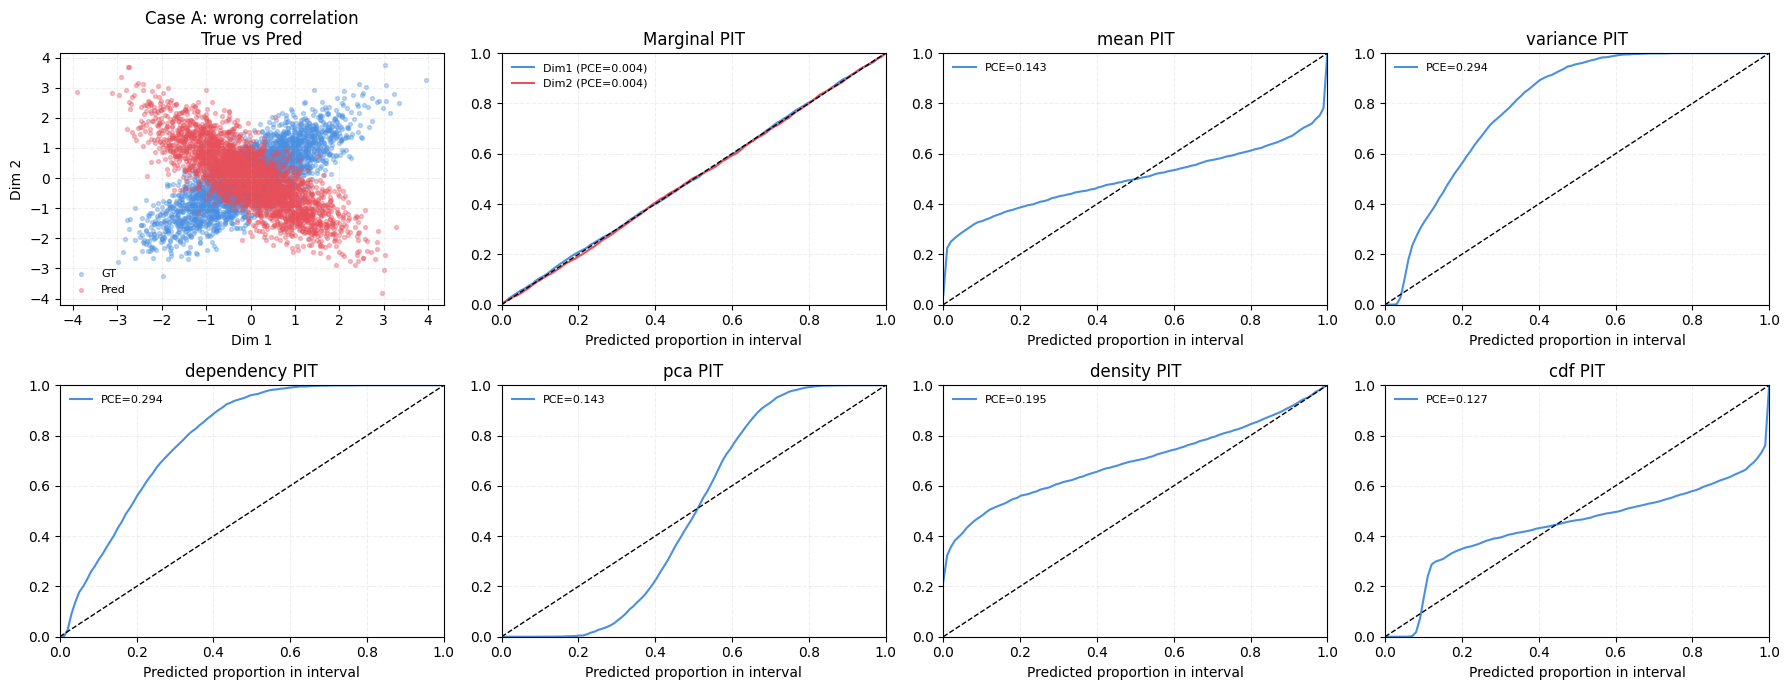

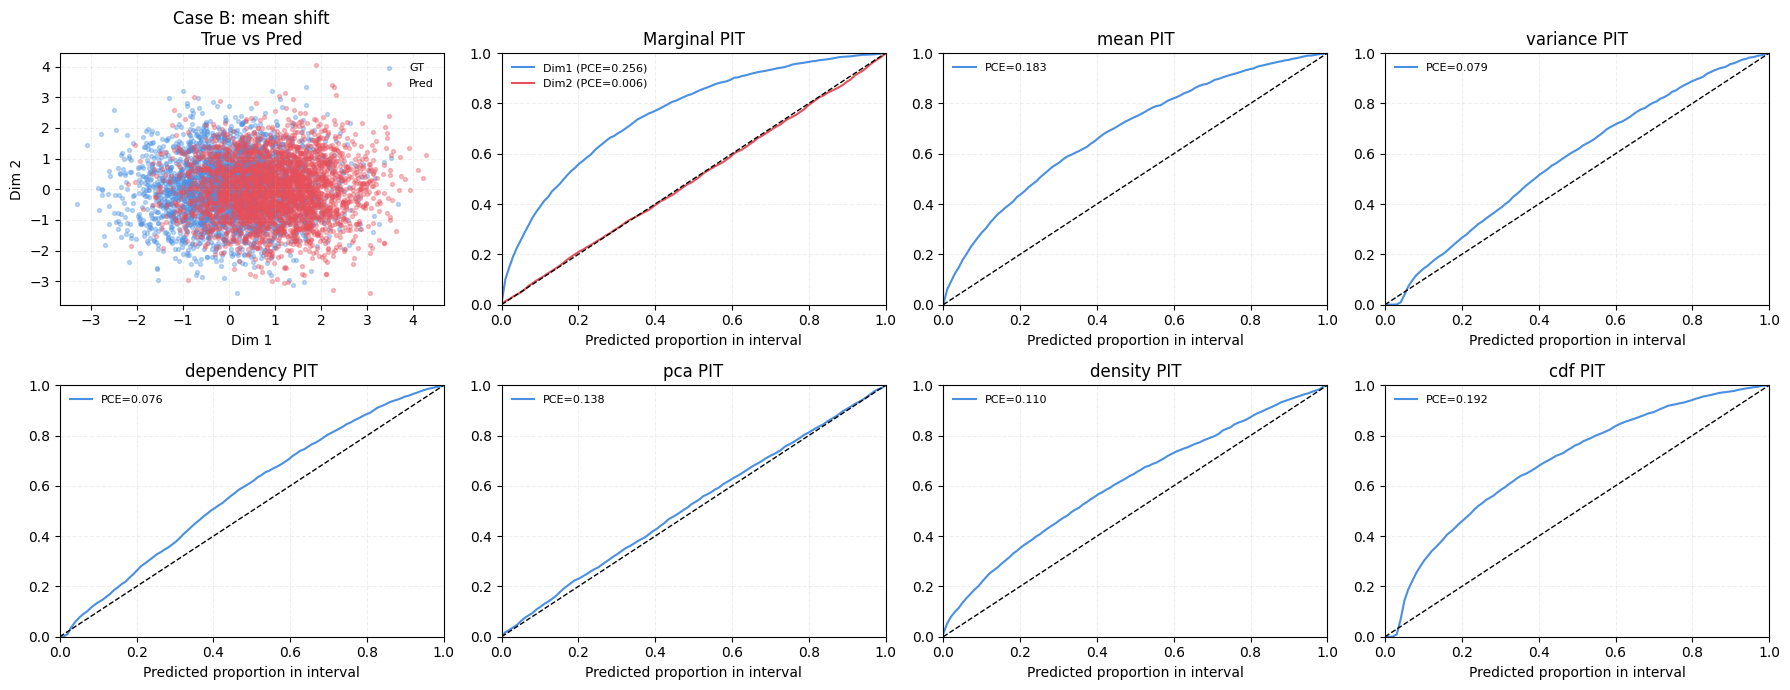

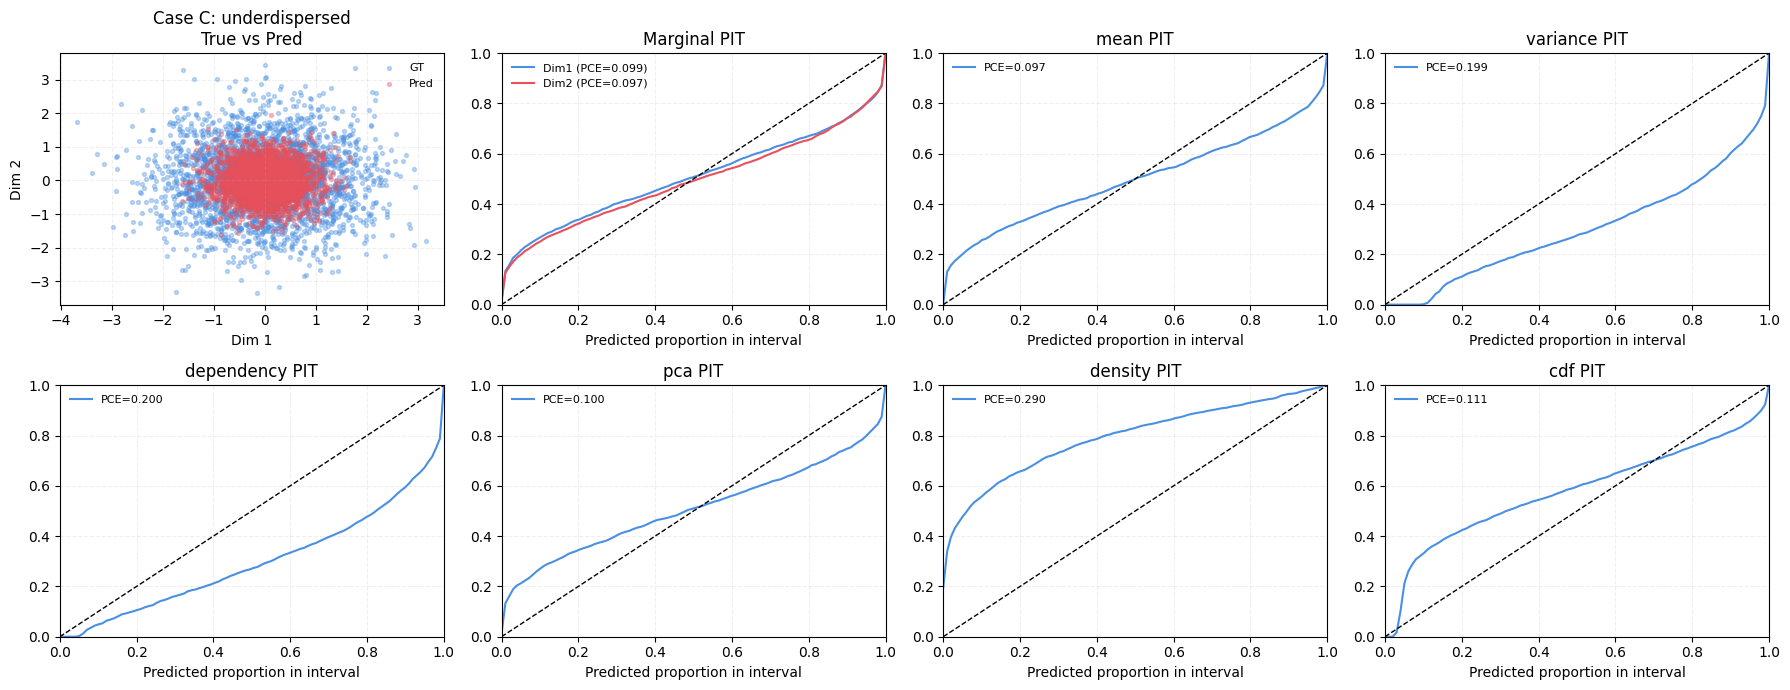

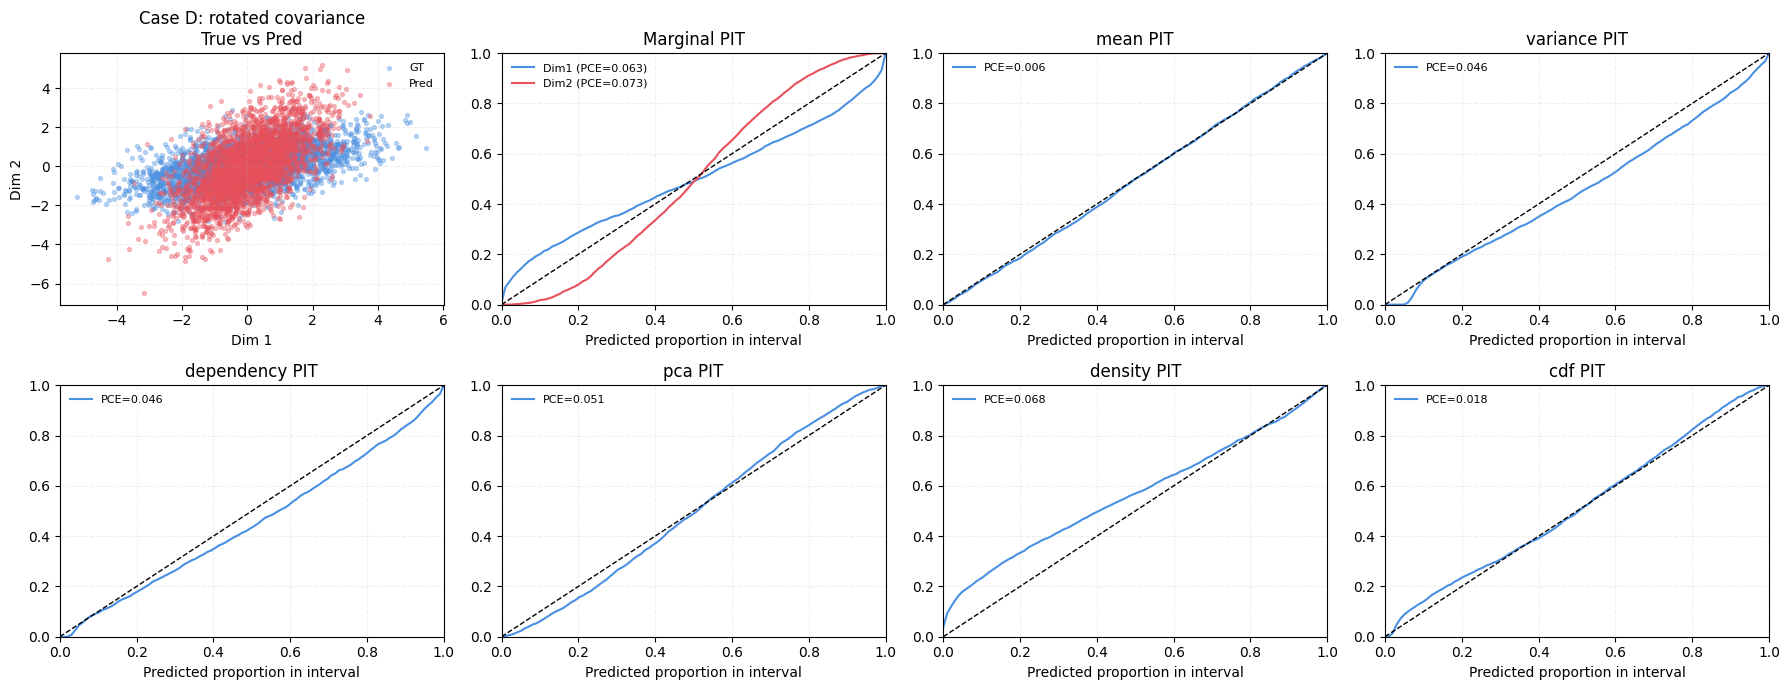

In [ ]:
# Plot each example with all prerank PIT curves
plot_case_all(
    "Case A: wrong correlation",
    mean_gt=np.array([0.0, 0.0]),
    cov_gt=np.array([[1.0, 0.8], [0.8, 1.0]]),
    mean_pred=np.array([0.0, 0.0]),
    cov_pred=np.array([[1.0, -0.8], [-0.8, 1.0]])
)

plot_case_all(
    "Case B: mean shift",
    mean_gt=np.array([0.0, 0.0]),
    cov_gt=np.eye(2),
    mean_pred=np.array([1.0, 0.0]),
    cov_pred=np.eye(2)
)

plot_case_all(
    "Case C: underdispersed",
    mean_gt=np.array([0.0, 0.0]),
    cov_gt=np.eye(2),
    mean_pred=np.array([0.0, 0.0]),
    cov_pred=0.25 * np.eye(2)
)

plot_case_all(
    "Case D: rotated covariance",
    mean_gt=np.array([0.0, 0.0]),
    cov_gt=cov_from_angle(20.0),
    mean_pred=np.array([0.0, 0.0]),
    cov_pred=cov_from_angle(60.0),
)

## Simulation study (aligned with Thorarinsdottir and Schuhen)

Below we match the misspecification scenarios in the study using a Gaussian with
covariance `Sigma_ij = sigma2 * exp(-|i-j|/tau)` and d=10, sigma2=1, tau=1 for the
true data. We then create **predicted** distributions with mean, variance, or
correlation misspecification.

In [ ]:
# Simulation study: cases matching Table 1 (mean / variance / correlation misspec)
np.random.seed(7)
torch.manual_seed(7)

# True data parameters
D = 10
sigma2_true = 1.0
tau_true = 1.0
mu_true = np.zeros(D)


def exp_decay_cov(d, sigma2, tau):
    idx = np.arange(d)
    dist = np.abs(idx[:, None] - idx[None, :])
    return sigma2 * np.exp(-dist / tau)


cov_true = exp_decay_cov(D, sigma2_true, tau_true)

# Predicted misspecifications (aligned with the study)
# mean shifts are applied to ALL dimensions for d=10 (scale of 0.5 as in the paper)
mu_under = np.full(D, -1.5)
mu_over = np.full(D, 1.5)

cases = [
    {
        "name": "Under-estimation of mean",
        "mu": mu_under,
        "sigma2": sigma2_true,
        "tau": tau_true,
    },
    {
        "name": "Over-estimation of mean",
        "mu": mu_over,
        "sigma2": sigma2_true,
        "tau": tau_true,
    },
    {
        "name": "Under-estimation of variance",
        "mu": mu_true,
        "sigma2": 0.55,
        "tau": tau_true,
    },
    {
        "name": "Over-estimation of variance",
        "mu": mu_true,
        "sigma2": 1.55,
        "tau": tau_true,
    },
    {
        "name": "Under-estimation of correlation",
        "mu": mu_true,
        "sigma2": sigma2_true,
        "tau": 0.25,
    },
    {
        "name": "Over-estimation of correlation",
        "mu": mu_true,
        "sigma2": sigma2_true,
        "tau": 2.50,
    },
]


# Build predicted covariances for each case
for c in cases:
    c["cov"] = exp_decay_cov(D, c["sigma2"], c["tau"])


# Example: generate data for each case (GT vs Pred) to plug into PIT plots
N_sim = 5000
GT = np.random.multivariate_normal(mu_true, cov_true, size=N_sim)

# Preview the case settings
for c in cases:
    print(f"{c['name']}: mu shift={c['mu'][0]:+0.2f}, sigma2={c['sigma2']}, tau={c['tau']}")

Under-estimation of mean: mu shift=-0.50, sigma2=1.0, tau=1.0
Over-estimation of mean: mu shift=+0.50, sigma2=1.0, tau=1.0
Under-estimation of variance: mu shift=+0.00, sigma2=0.55, tau=1.0
Over-estimation of variance: mu shift=+0.00, sigma2=1.55, tau=1.0
Under-estimation of correlation: mu shift=+0.00, sigma2=1.0, tau=0.25
Over-estimation of correlation: mu shift=+0.00, sigma2=1.0, tau=2.5


In [17]:
# Create predicted distributions that follow the study (batch MVN per case)

case_dists = []
for c in cases:
    dist_pred = MultivariateNormal(
        loc=torch.tensor(c["mu"], dtype=torch.float32).repeat(N_sim, 1),
        covariance_matrix=torch.tensor(c["cov"], dtype=torch.float32).expand(N_sim, D, D)
    )
    case_dists.append(dist_pred)

# Show shapes to confirm
print("GT shape:", GT.shape)
print("Example pred batch shape:", case_dists[0].mean.shape)

GT shape: (5000, 10)
Example pred batch shape: torch.Size([5000, 10])


## Redundancy analysis between preranks

We quantify overlap between preranks by computing **Spearman correlations** between
PIT vectors induced by each prerank. High correlation suggests redundancy, while
low correlation indicates complementary information.

In [27]:
from scipy.stats import spearmanr

# Compute Spearman rank-correlation between prerank PIT vectors
prerank_list = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']


def _pit_vector(dist_pred_batch, y_t, prerank, n_samples=200):
    # calculate_PIT returns pits with shape (n_scores, N, 1)
    pits, _ = calculate_PIT(dist_pred_batch, y_t, n_samples=n_samples, prerank=prerank, setup='real')
    pits = pits.squeeze(-1)  # (n_scores, N)
    # average across multiple scores (e.g. marginal dims or PCA components)
    pit_vec = pits.mean(dim=0)
    return pit_vec.detach().cpu().numpy()


def plot_prerank_redundancy(case_name, dist_pred_batch, y_t, n_samples=200):
    pit_matrix = []
    for pr in prerank_list:
        pit_matrix.append(_pit_vector(dist_pred_batch, y_t, pr, n_samples=n_samples))
    pit_matrix = np.stack(pit_matrix, axis=1)  # (N, R)

    corr = spearmanr(pit_matrix).correlation  # (R, R)

    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(
        corr,
        vmin=-1, vmax=1, cmap='coolwarm',
        xticklabels=prerank_list,
        yticklabels=prerank_list,
        square=True,
        cbar_kws={'label': 'Spearman correlation'}
    )
    plt.title(f"Prerank redundancy (Spearman)\n{case_name}")
    plt.tight_layout()
    plt.show()

Average Spearman correlation across cases:


,marginal,mean,variance,dependency,pca,density,cdf
marginal,1.000000,0.974972,-0.020375,0.007509,0.339968,0.009039,0.499721
mean,0.974972,1.000000,-0.019960,0.006887,0.340963,0.008964,0.495052
variance,-0.020375,-0.019960,1.000000,0.361849,-0.017884,-0.813329,-0.201361
dependency,0.007509,0.006887,0.361849,1.000000,0.005832,-0.013857,-0.048997
pca,0.339968,0.340963,-0.017884,0.005832,1.000000,0.012392,0.192741
density,0.009039,0.008964,-0.813329,-0.013857,0.012392,1.000000,0.074571
cdf,0.499721,0.495052,-0.201361,-0.048997,0.192741,0.074571,1.000000


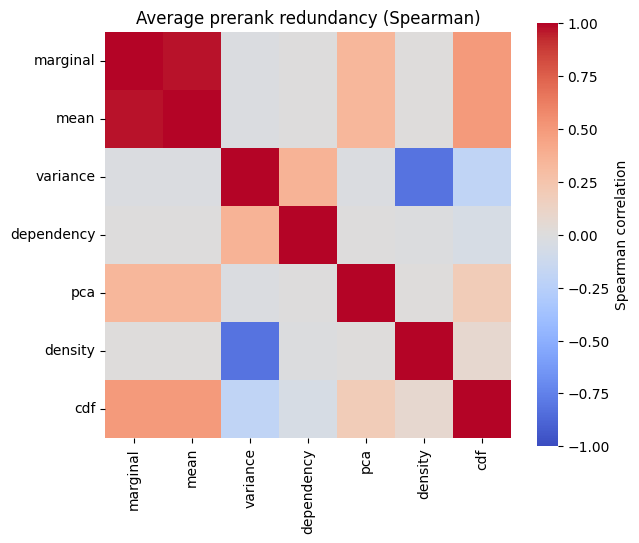

In [28]:
# Average redundancy across all misspecification cases
corr_list = []
for c, dist_pred in zip(cases, case_dists):
    pit_matrix = []
    for pr in prerank_list:
        pit_matrix.append(_pit_vector(dist_pred, y_t, pr, n_samples=200))
    pit_matrix = np.stack(pit_matrix, axis=1)  # (N, R)
    corr = spearmanr(pit_matrix).correlation  # (R, R)
    corr_list.append(corr)

avg_corr = np.nanmean(np.stack(corr_list, axis=0), axis=0)

# Table view
avg_corr_df = pd.DataFrame(avg_corr, index=prerank_list, columns=prerank_list)
print("Average Spearman correlation across cases:")
display(avg_corr_df)

# Heatmap view
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    avg_corr,
    vmin=-1, vmax=1, cmap='coolwarm',
    xticklabels=prerank_list,
    yticklabels=prerank_list,
    square=True,
    cbar_kws={'label': 'Spearman correlation'}
)
plt.title("Average prerank redundancy (Spearman)")
plt.tight_layout()
plt.show()

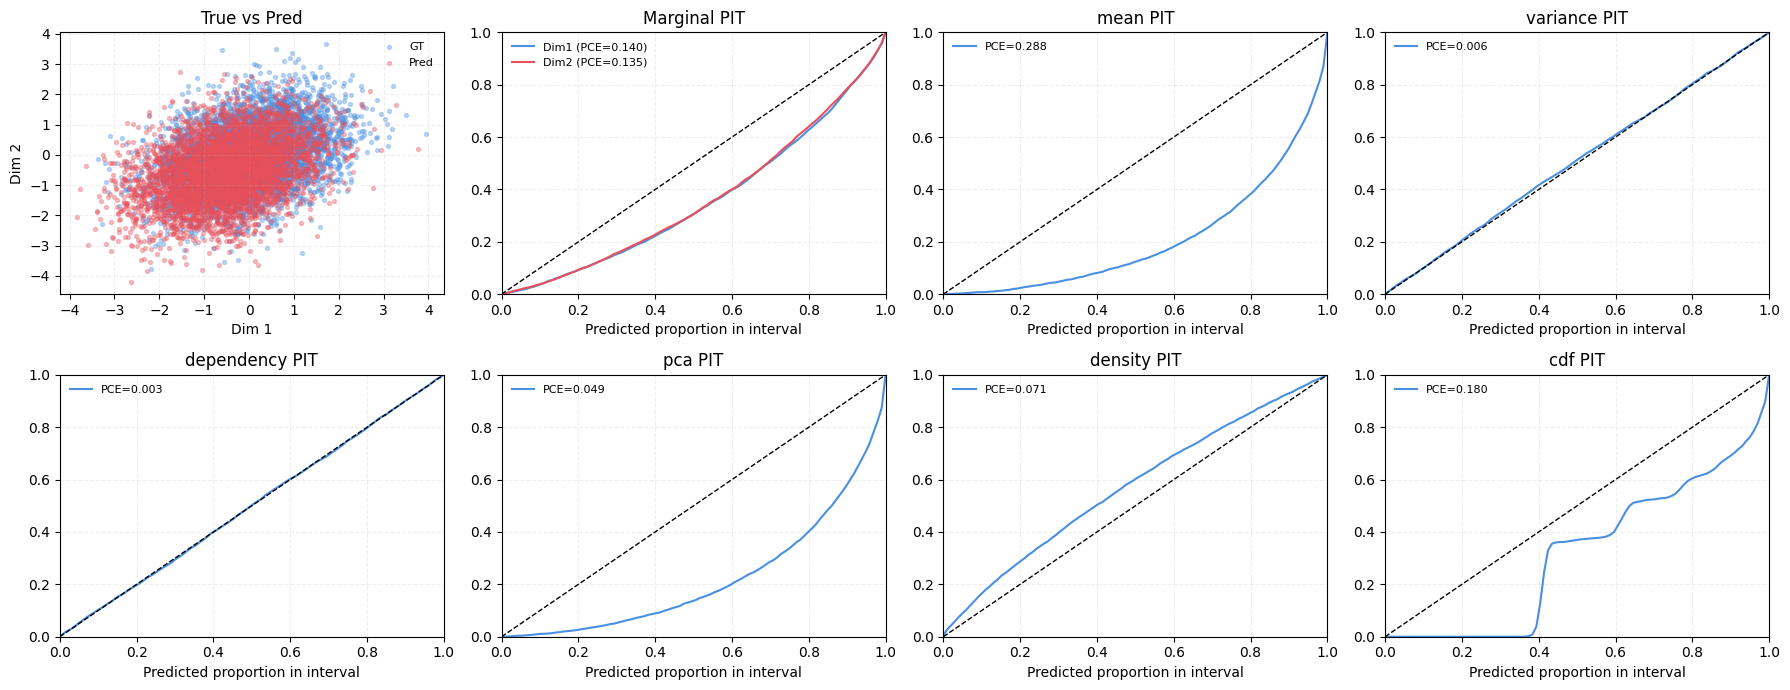

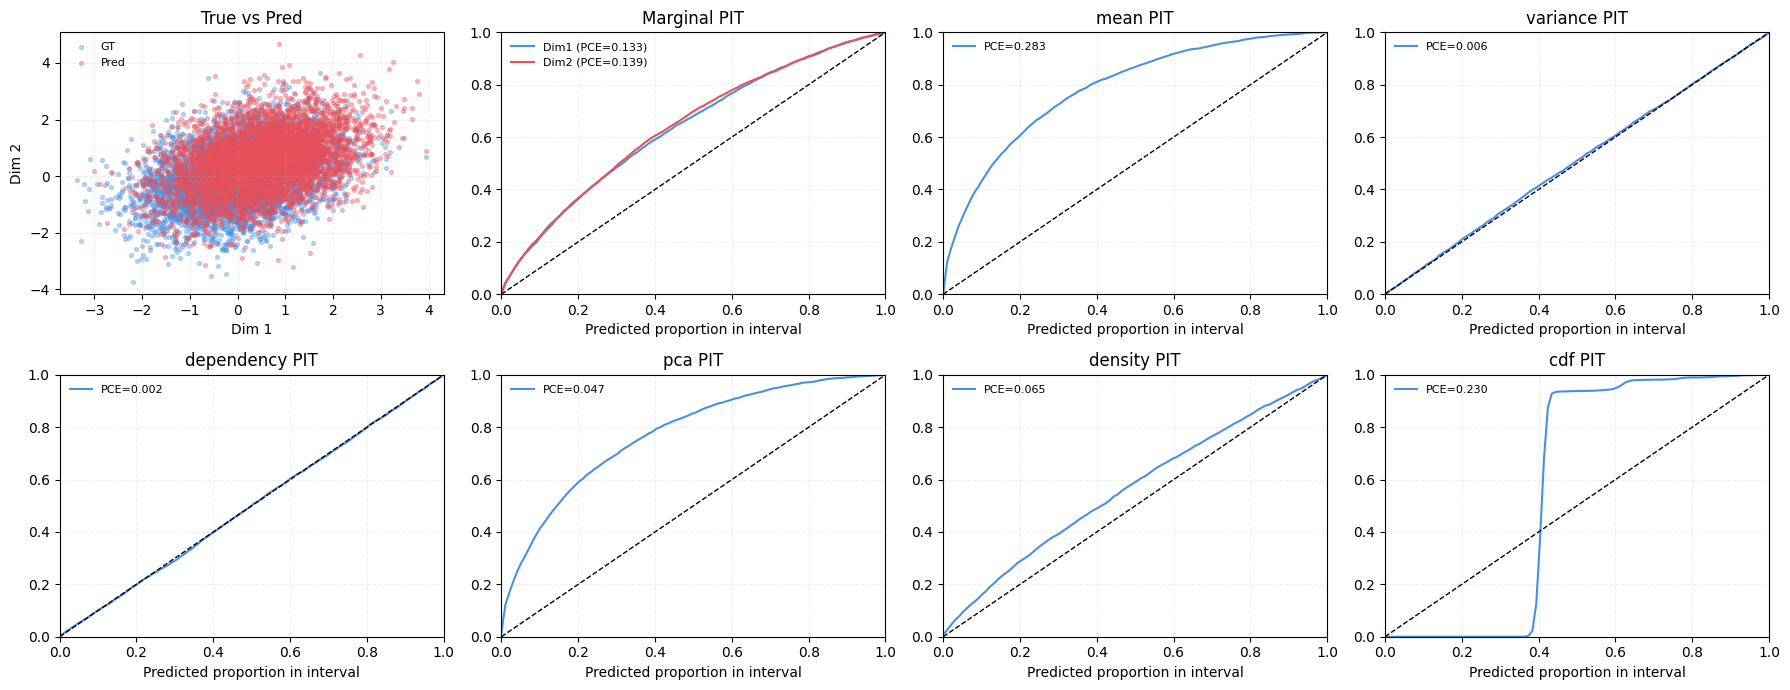

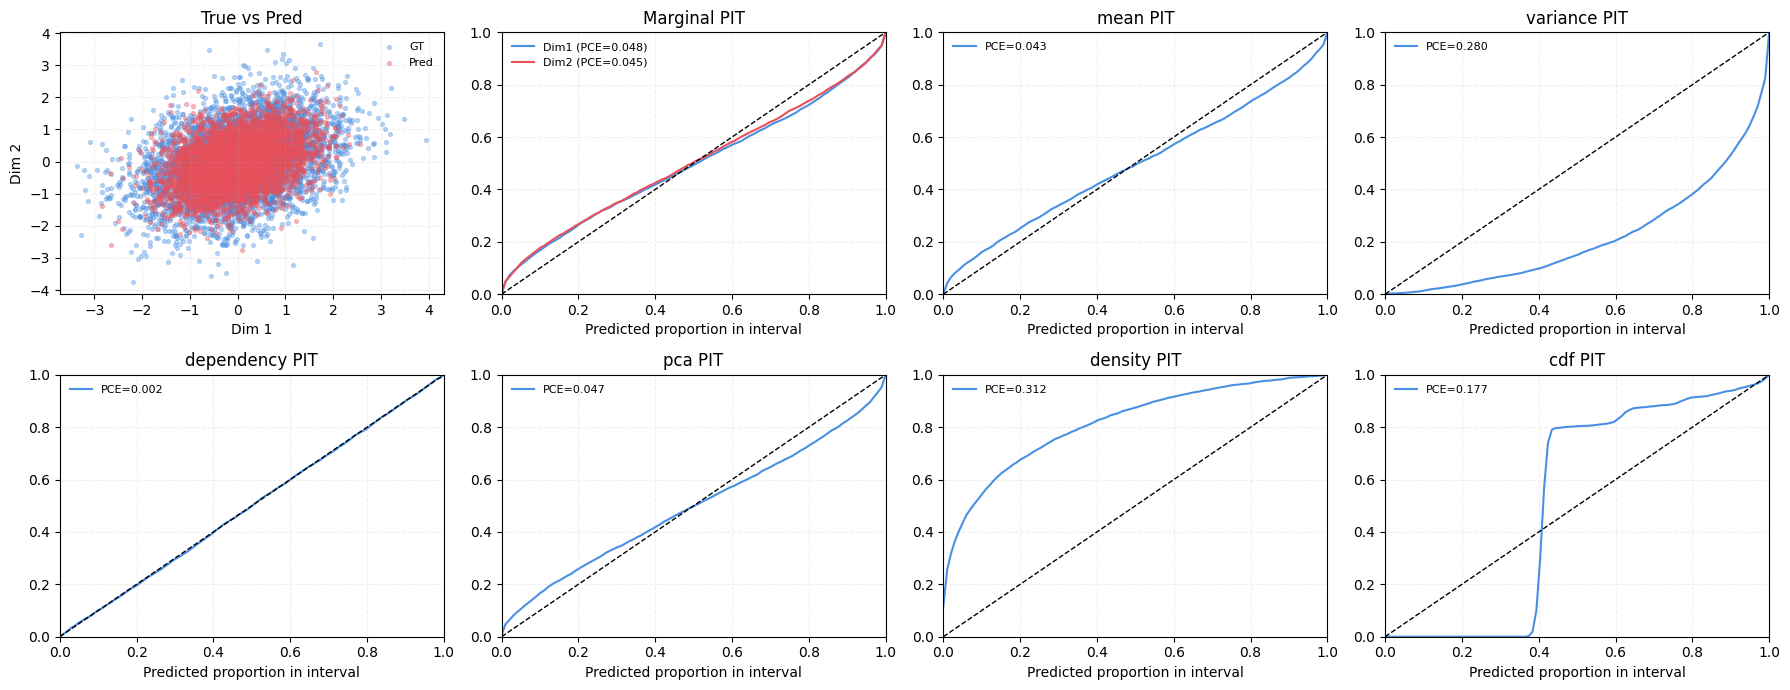

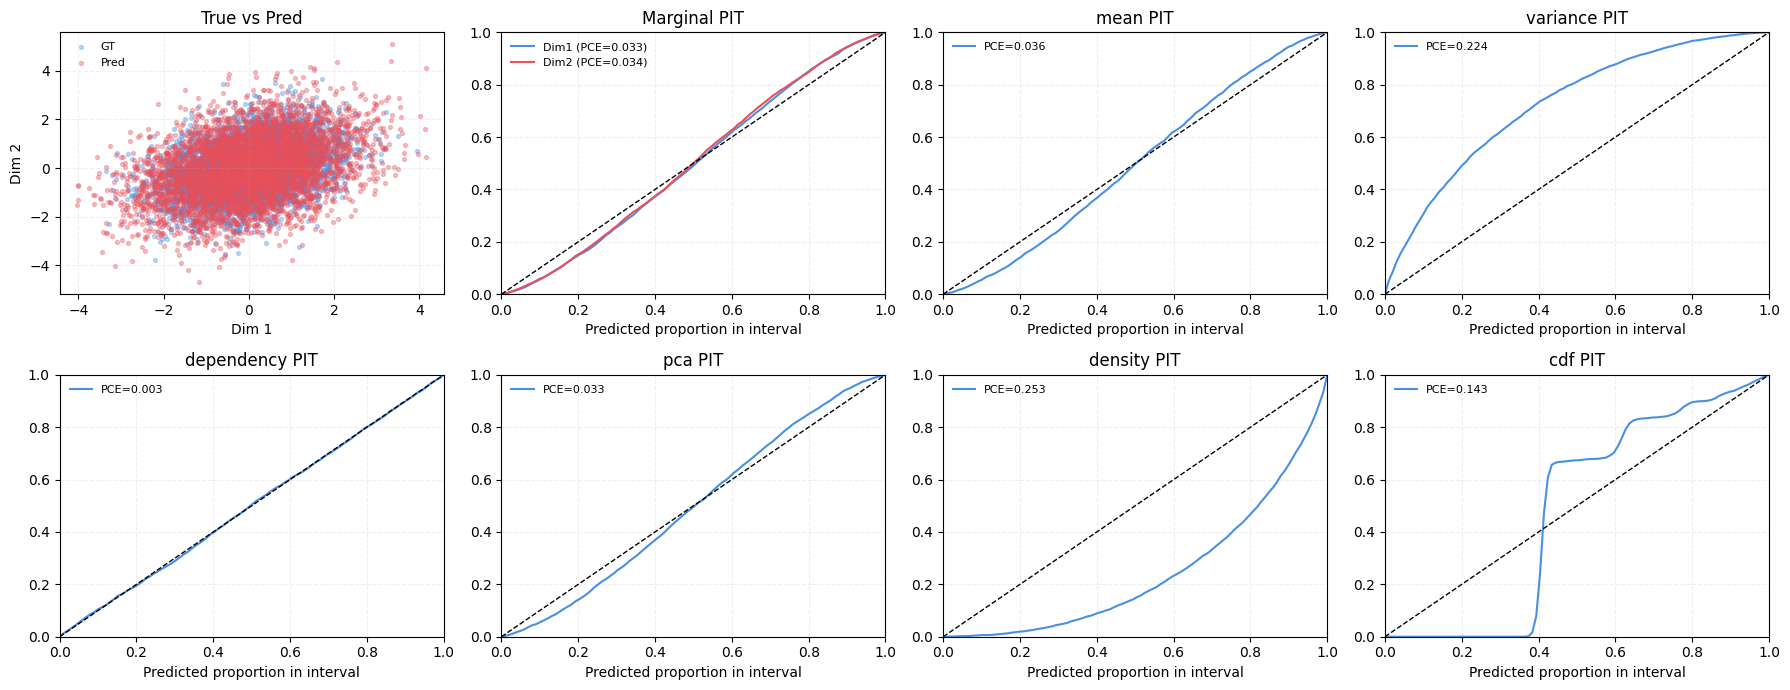

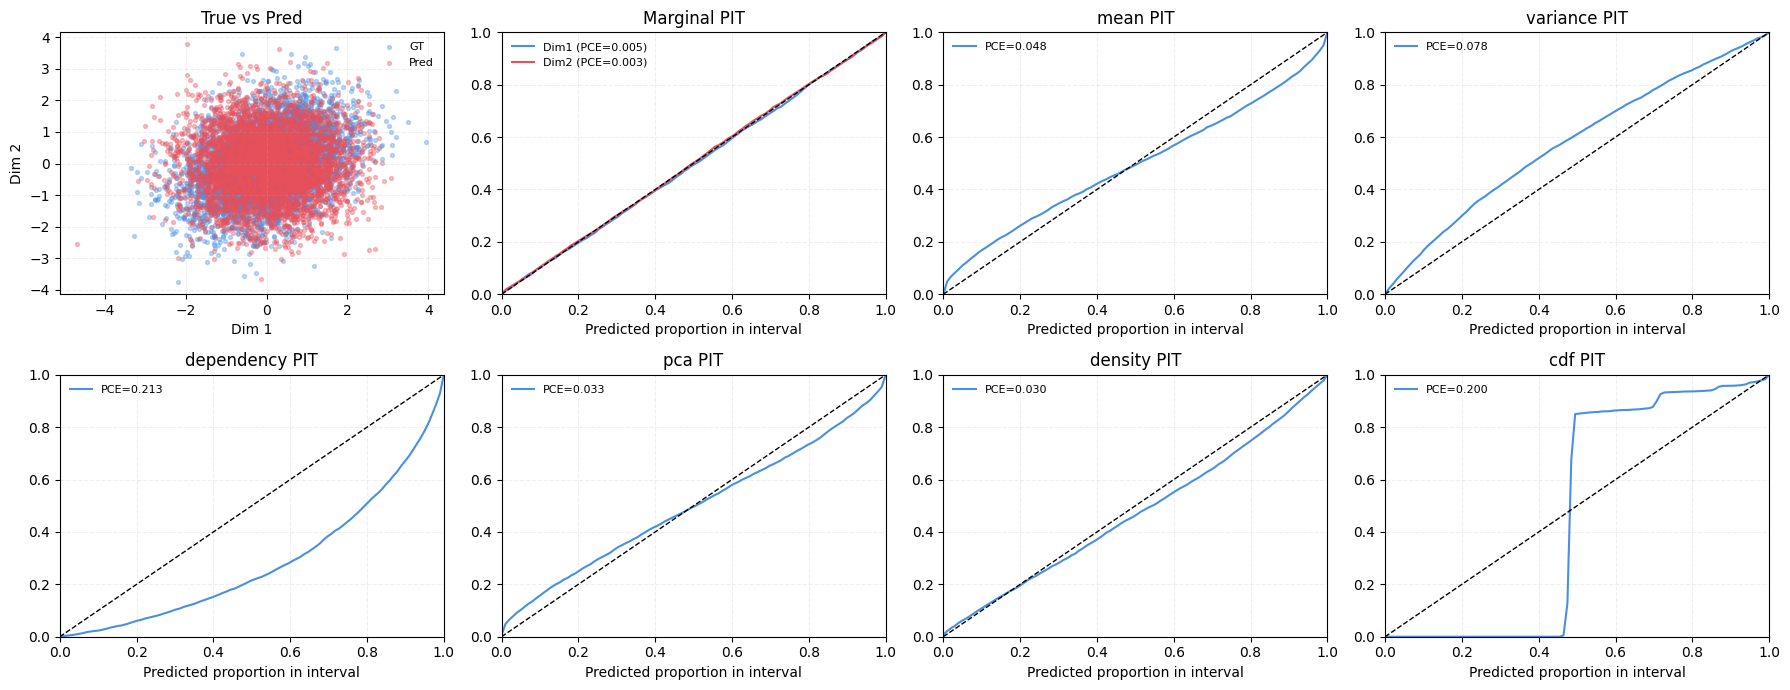

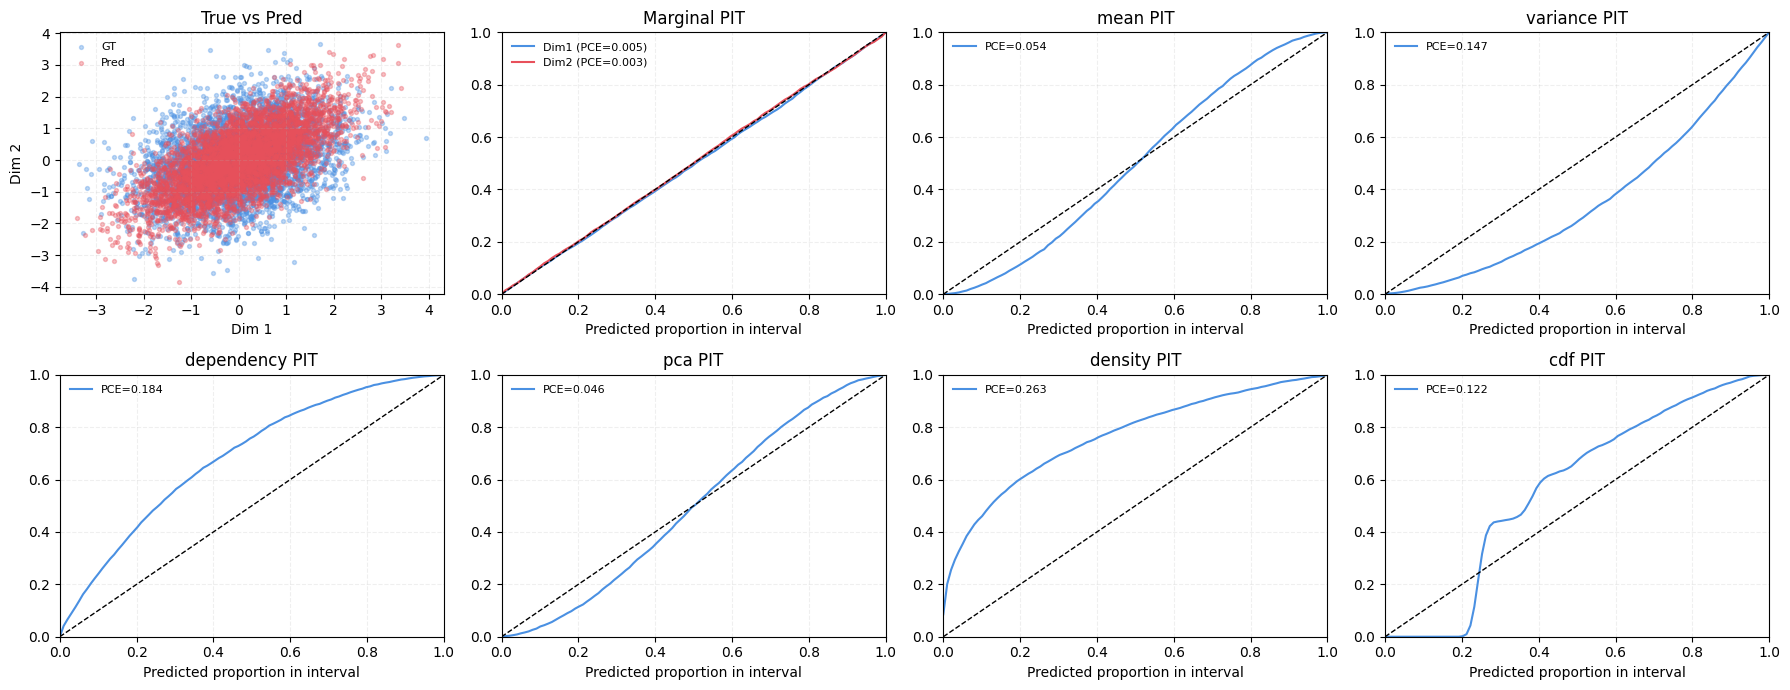

In [ ]:
# Full grid of prerank reliability plots for each misspecification

y_t = torch.tensor(GT, dtype=torch.float32)

def plot_prerank_grid(case_name, dist_pred_batch, n_samples=200):

    pred_samples = dist_pred_batch.sample().cpu().numpy()  # (N_sim, D)

    # Marginal PIT curves (one per dimension)
    pce_marg, cdfs_marg = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank='marginal', setup='real')
    cdf_dim1 = cdfs_marg[0].cpu().numpy()
    cdf_dim2 = cdfs_marg[1].cpu().numpy()

    fig, axs = plt.subplots(2, 4, figsize=(18, 7))

    # (1) Distribution scatter
    axs[0, 0].scatter(GT[:, 0], GT[:, 1], s=8, alpha=0.35, label='GT', color='#4A90E2')
    axs[0, 0].scatter(pred_samples[:, 0], pred_samples[:, 1], s=8, alpha=0.35, label='Pred', color='#E8505B')
    axs[0, 0].set_title('True vs Pred')
    axs[0, 0].set_xlabel('Dim 1'); axs[0, 0].set_ylabel('Dim 2')
    axs[0, 0].legend(frameon=False, fontsize=8)
    axs[0, 0].grid(alpha=0.2, linestyle='--')

    # (2) Marginal reliability
    axs[0, 1].plot(alphas, cdf_dim1, label=f'Dim1 (PCE={float(pce_marg[0]):.3f})', color='#4A90E2')
    axs[0, 1].plot(alphas, cdf_dim2, label=f'Dim2 (PCE={float(pce_marg[1]):.3f})', color='#E8505B')
    axs[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
    axs[0, 1].set_title('Marginal PIT')
    axs[0, 1].set_xlabel('Predicted proportion in interval')
    axs[0, 1].set_xlim(0, 1); axs[0, 1].set_ylim(0, 1)
    axs[0, 1].grid(alpha=0.2, linestyle='--')
    axs[0, 1].legend(frameon=False, fontsize=8)

    # (3) Other preranks
    other_preranks = ['mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
    pit_curves = {}
    for pr in other_preranks:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        pit_curves[pr] = (cdfs_pr[0].cpu().numpy(), float(pce_pr.mean()))

    _plot_reliability(axs[0, 2], pit_curves['mean'][0], pit_curves['mean'][1], 'mean PIT')
    _plot_reliability(axs[0, 3], pit_curves['variance'][0], pit_curves['variance'][1], 'variance PIT')
    _plot_reliability(axs[1, 0], pit_curves['dependency'][0], pit_curves['dependency'][1], 'dependency PIT')
    _plot_reliability(axs[1, 1], pit_curves['pca'][0], pit_curves['pca'][1], 'pca PIT')
    _plot_reliability(axs[1, 2], pit_curves['density'][0], pit_curves['density'][1], 'density PIT')
    _plot_reliability(axs[1, 3], pit_curves['cdf'][0], pit_curves['cdf'][1], 'cdf PIT')

    plt.tight_layout()
    plt.show()


# Generate the grid for each misspecification case
for c, dist_pred in zip(cases, case_dists):
    plot_prerank_grid(c['name'], dist_pred, n_samples=200)

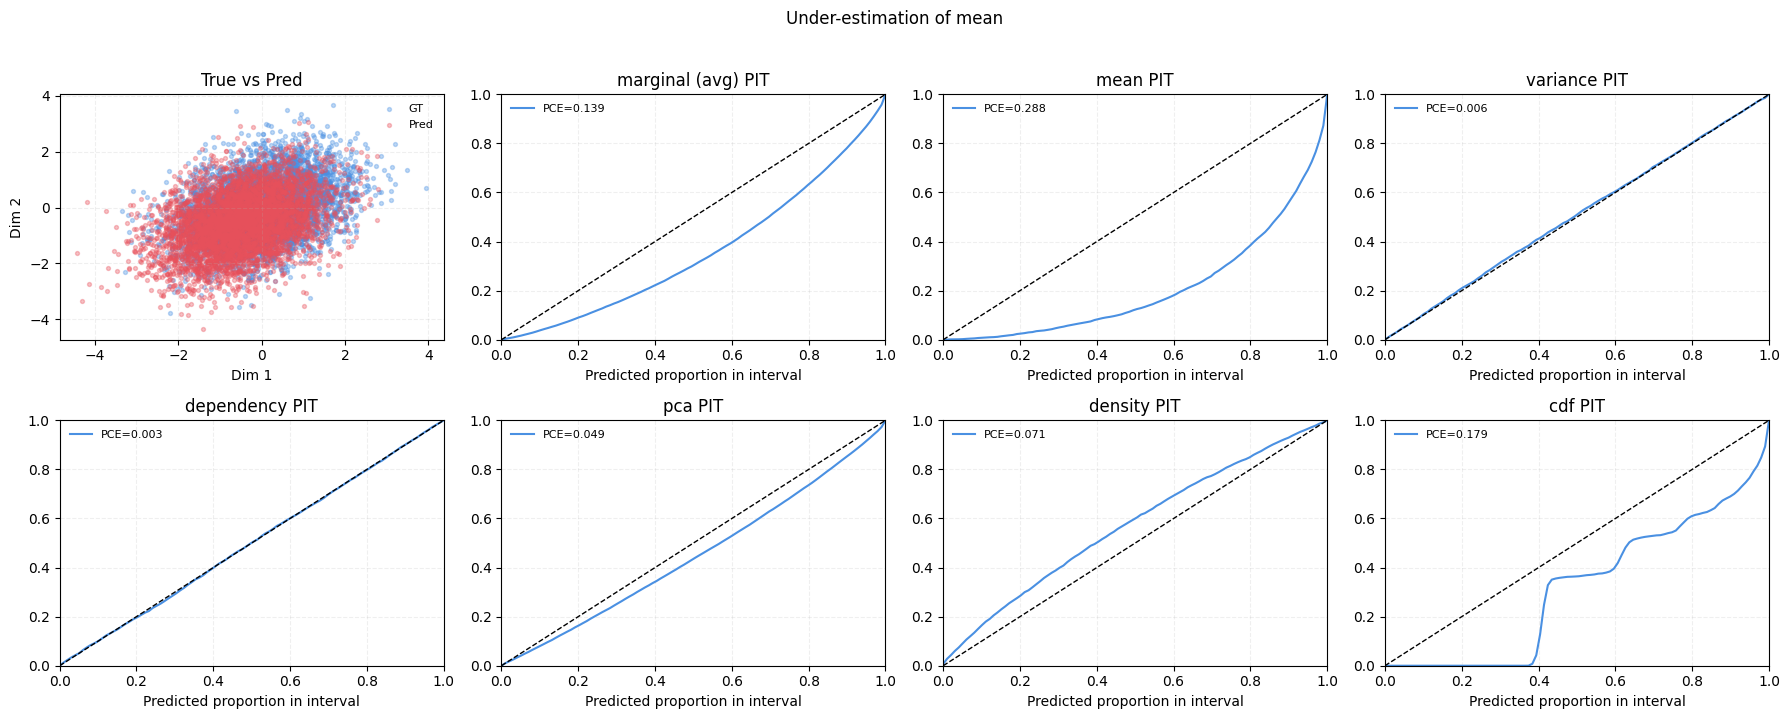

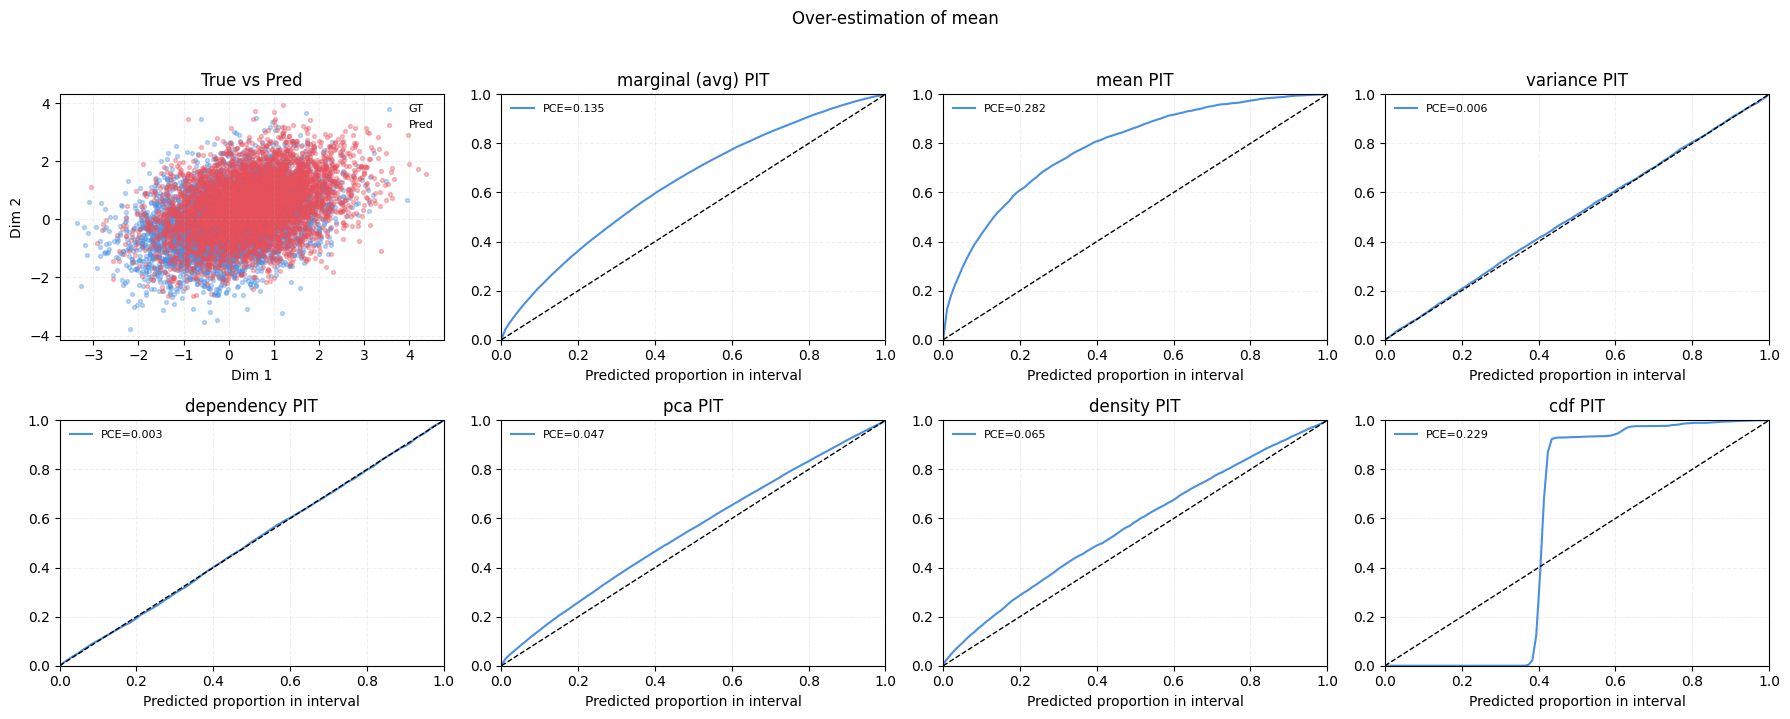

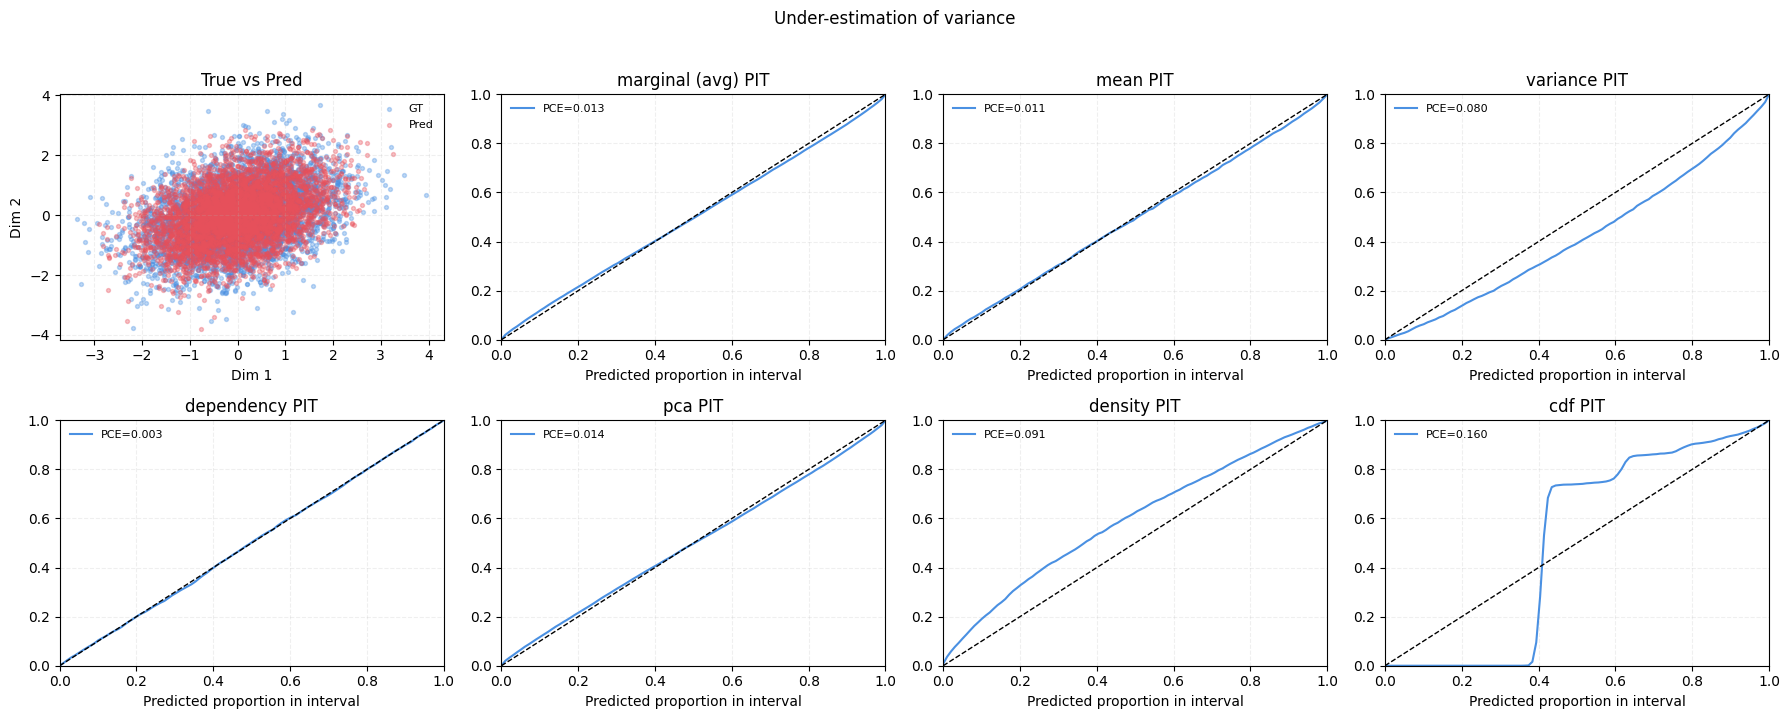

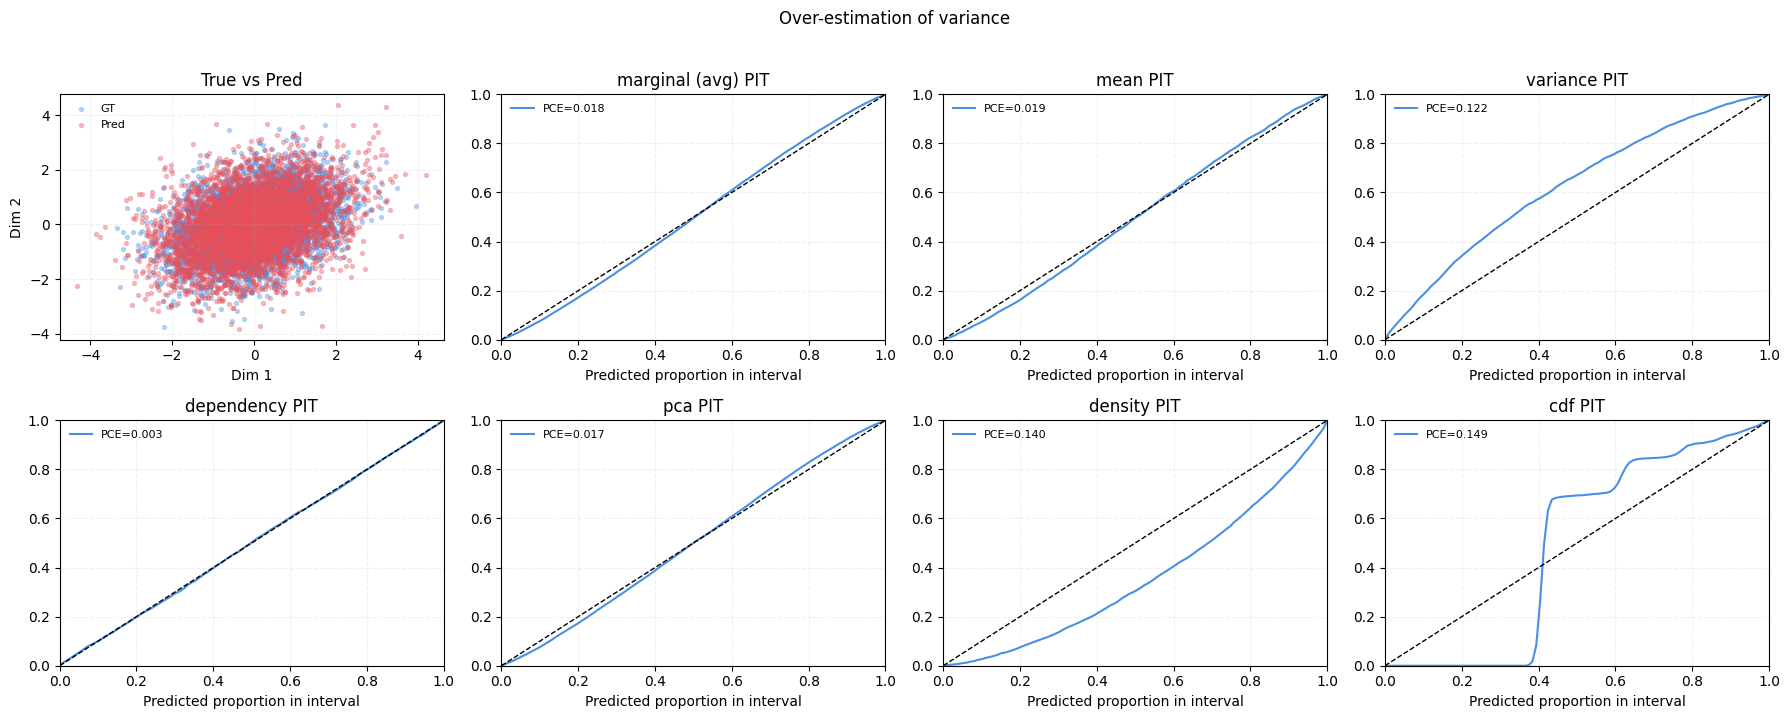

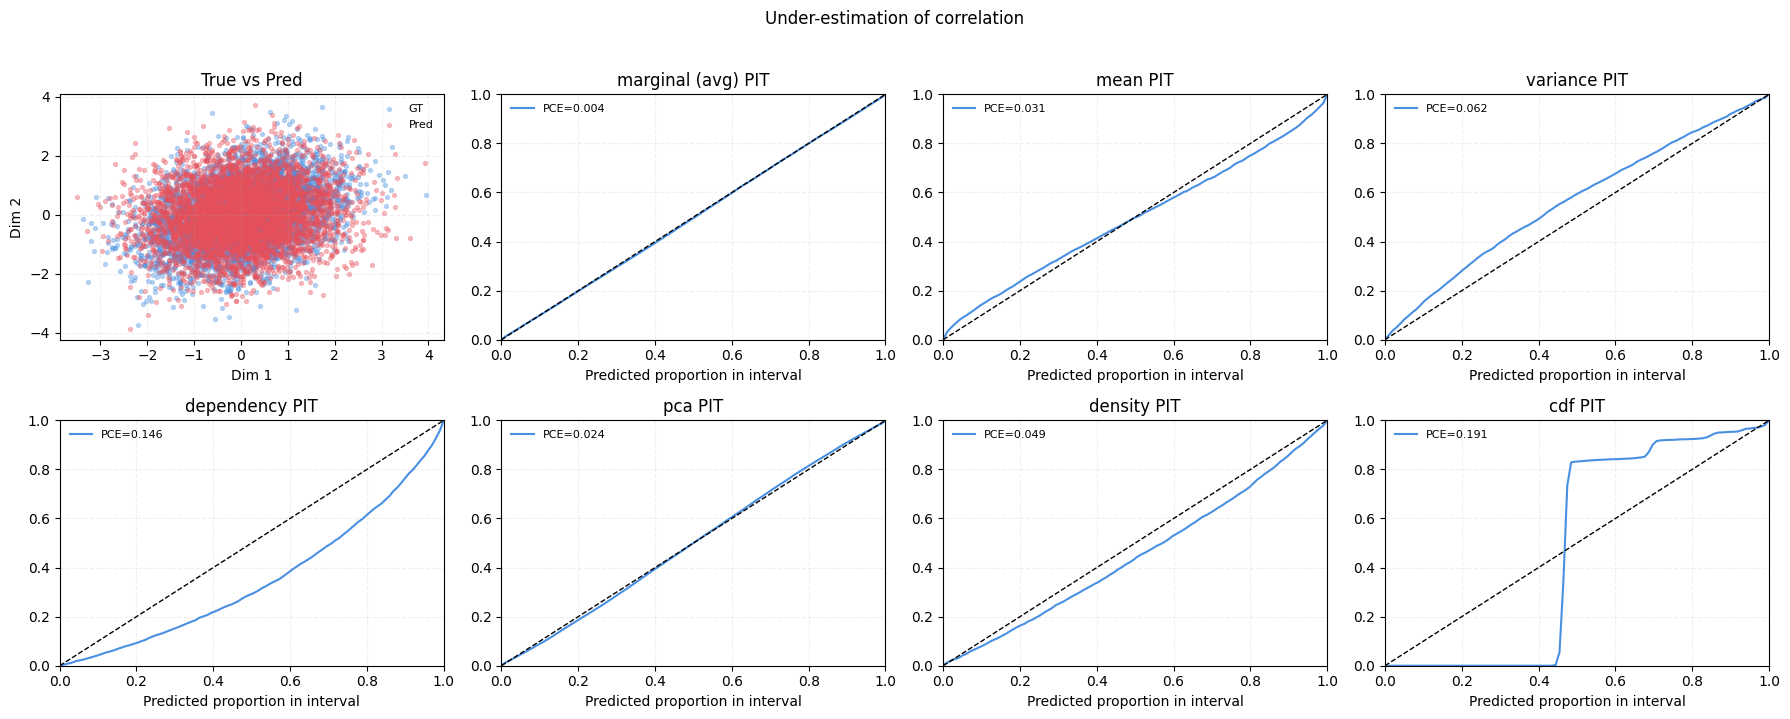

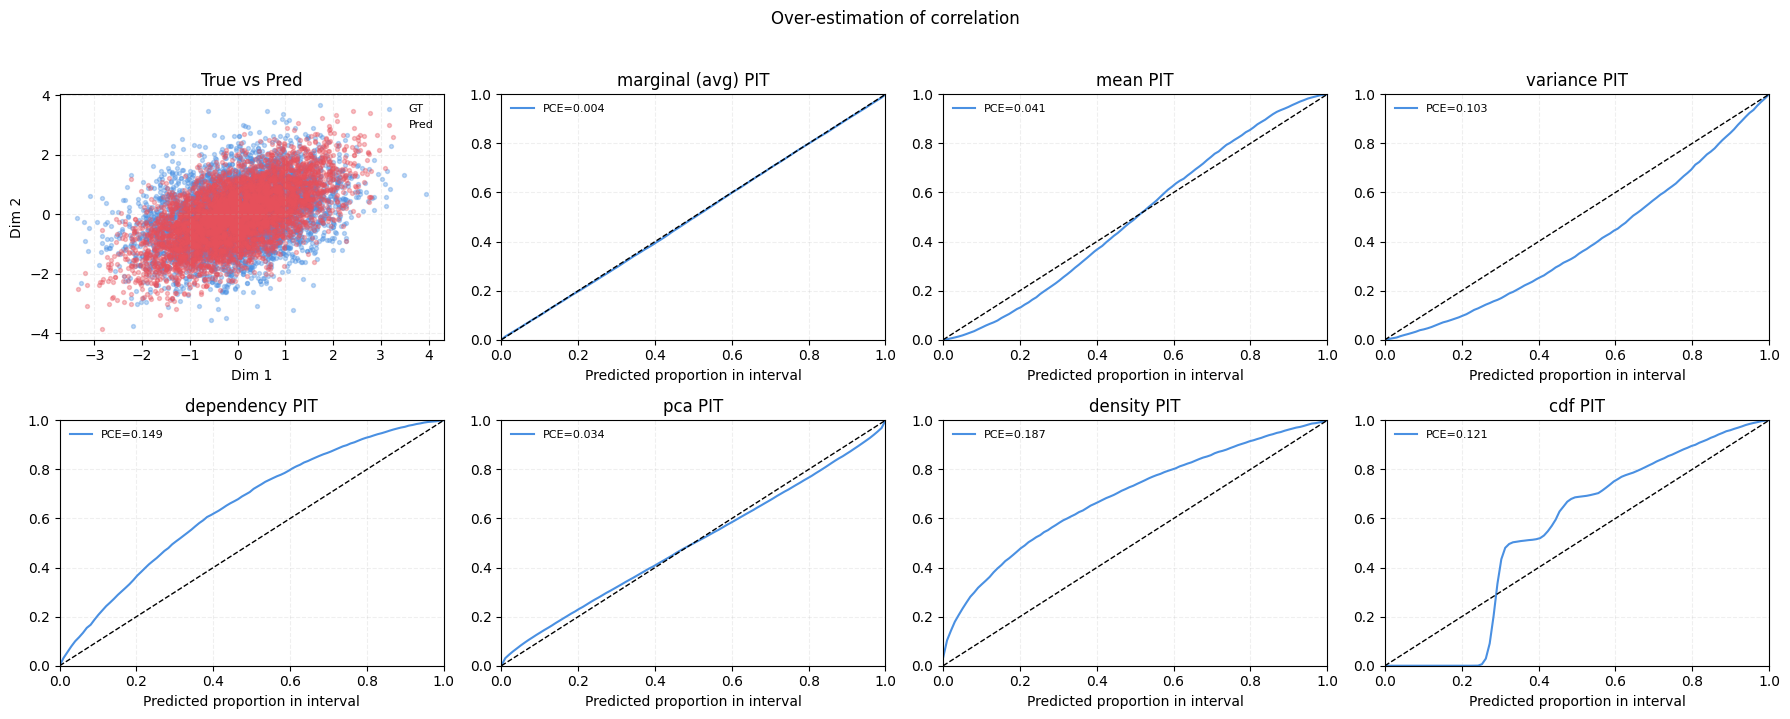

In [ ]:
# Full grid of prerank reliability plots for each misspecification

y_t = torch.tensor(GT, dtype=torch.float32)

def _mean_cdf_and_pce(cdfs, pces):
    # Average over multiple curves (e.g., marginal dims or PCA components)
    cdf_mean = cdfs.mean(dim=0).cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean


def plot_prerank_grid(case_name, dist_pred_batch, n_samples=200):
    fig, axs = plt.subplots(2, 4, figsize=(18, 7))

    # True vs predicted distribution (sample from batch MVN)
    pred_samples = dist_pred_batch.sample().cpu().numpy()  # (N_sim, D)
    axs[0, 0].scatter(GT[:, 0], GT[:, 1], s=8, alpha=0.35, label='GT', color='#4A90E2')
    axs[0, 0].scatter(pred_samples[:, 0], pred_samples[:, 1], s=8, alpha=0.35, label='Pred', color='#E8505B')
    axs[0, 0].set_title('True vs Pred')
    axs[0, 0].set_xlabel('Dim 1'); axs[0, 0].set_ylabel('Dim 2')
    axs[0, 0].legend(frameon=False, fontsize=8)
    axs[0, 0].grid(alpha=0.2, linestyle='--')

    # Marginal (average over dims)
    pce_marg, cdfs_marg = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank='marginal', setup='real')
    cdf_marg, pce_m = _mean_cdf_and_pce(cdfs_marg, pce_marg)
    _plot_reliability(axs[0, 1], cdf_marg, pce_m, 'marginal (avg) PIT')

    # Mean / variance / dependency
    for ax, pr in [(axs[0, 2], 'mean'), (axs[0, 3], 'variance'), (axs[1, 0], 'dependency')]:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        cdf_pr, pce_pr_mean = _mean_cdf_and_pce(cdfs_pr, pce_pr)
        _plot_reliability(ax, cdf_pr, pce_pr_mean, f'{pr} PIT')

    # PCA / density / CDF
    for ax, pr in [(axs[1, 1], 'pca'), (axs[1, 2], 'density'), (axs[1, 3], 'cdf')]:
        pce_pr, cdfs_pr = pce(dist_pred_batch, y_t, n_samples=n_samples, prerank=pr, setup='real')
        cdf_pr, pce_pr_mean = _mean_cdf_and_pce(cdfs_pr, pce_pr)
        _plot_reliability(ax, cdf_pr, pce_pr_mean, f'{pr} PIT')

    fig.suptitle(case_name, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


# Generate the grid for each misspecification case
for c, dist_pred in zip(cases, case_dists):
    plot_prerank_grid(c['name'], dist_pred, n_samples=200)

In [3]:
D = 10

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_batch_mvn(mean, cov, n):
    mean = torch.tensor(mean, dtype=torch.float32, device=device).expand(n, -1)
    cov = torch.tensor(cov, dtype=torch.float32, device=device).expand(n, -1, -1)
    return torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)

N = 5000
mu_true = np.zeros(D)
cov_true = exp_decay_cov(D, sigma2_true, tau_true)

dist_true = torch.distributions.MultivariateNormal(
    torch.tensor(mu_true, dtype=torch.float32, device=device),
    covariance_matrix=torch.tensor(cov_true, dtype=torch.float32, device=device),
)
y = dist_true.sample((N,))

mean_shift = np.full(D, 0.8)
cov_var_under = exp_decay_cov(D, sigma2_true * 0.5, tau_true)
cov_var_over = exp_decay_cov(D, sigma2_true * 1.4, tau_true)
cov_corr_under = exp_decay_cov(D, sigma2_true, tau_true * 0.3)
cov_corr_over = exp_decay_cov(D, sigma2_true, tau_true * 3.0)

anis_factors = np.ones(D)
anis_factors[:max(1, D//2)] = 2.5
cov_aniso = np.diag(anis_factors) @ cov_true @ np.diag(anis_factors)

cases = [
    ("Well-specified", mu_true, cov_true),
    ("Mean shift", mean_shift, cov_true),
    ("Var under", mu_true, cov_var_under),
    ("Var over", mu_true, cov_var_over),
    ("Corr under", mu_true, cov_corr_under),
    ("Corr over", mu_true, cov_corr_over),
    ("Anisotropy", mu_true, cov_aniso),
]

preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

alphas = np.linspace(0, 1, 100)

def _mean_cdf_and_pce(cdfs, pces):
    cdf_mean = cdfs.mean(dim=0).detach().cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean

fig, axs = plt.subplots(len(preranks), len(cases),
                        figsize=(2.4 * len(cases), 1.8 * len(preranks)),
                        sharex=True, sharey=True)

for j, (name, mu_pred, cov_pred) in enumerate(cases):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N)
    for i, pr in enumerate(preranks):
        pces, cdfs = pce(dist_pred, y, n_samples=1000, prerank=pr, setup="real")
        cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
        ax = axs[i, j]
        ax.plot(alphas, cdf_mean, color="0.2", lw=1)
        ax.plot([0, 1], [0, 1], "r--", lw=0.8)
        if i == 0:
            ax.set_title(name, fontsize=9)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([])
        ax.text(0.02, 0.92, f"PCE={pce_mean:.3f}", transform=ax.transAxes, fontsize=7)

plt.tight_layout()
plt.show()

NameError: name 'exp_decay_cov' is not defined

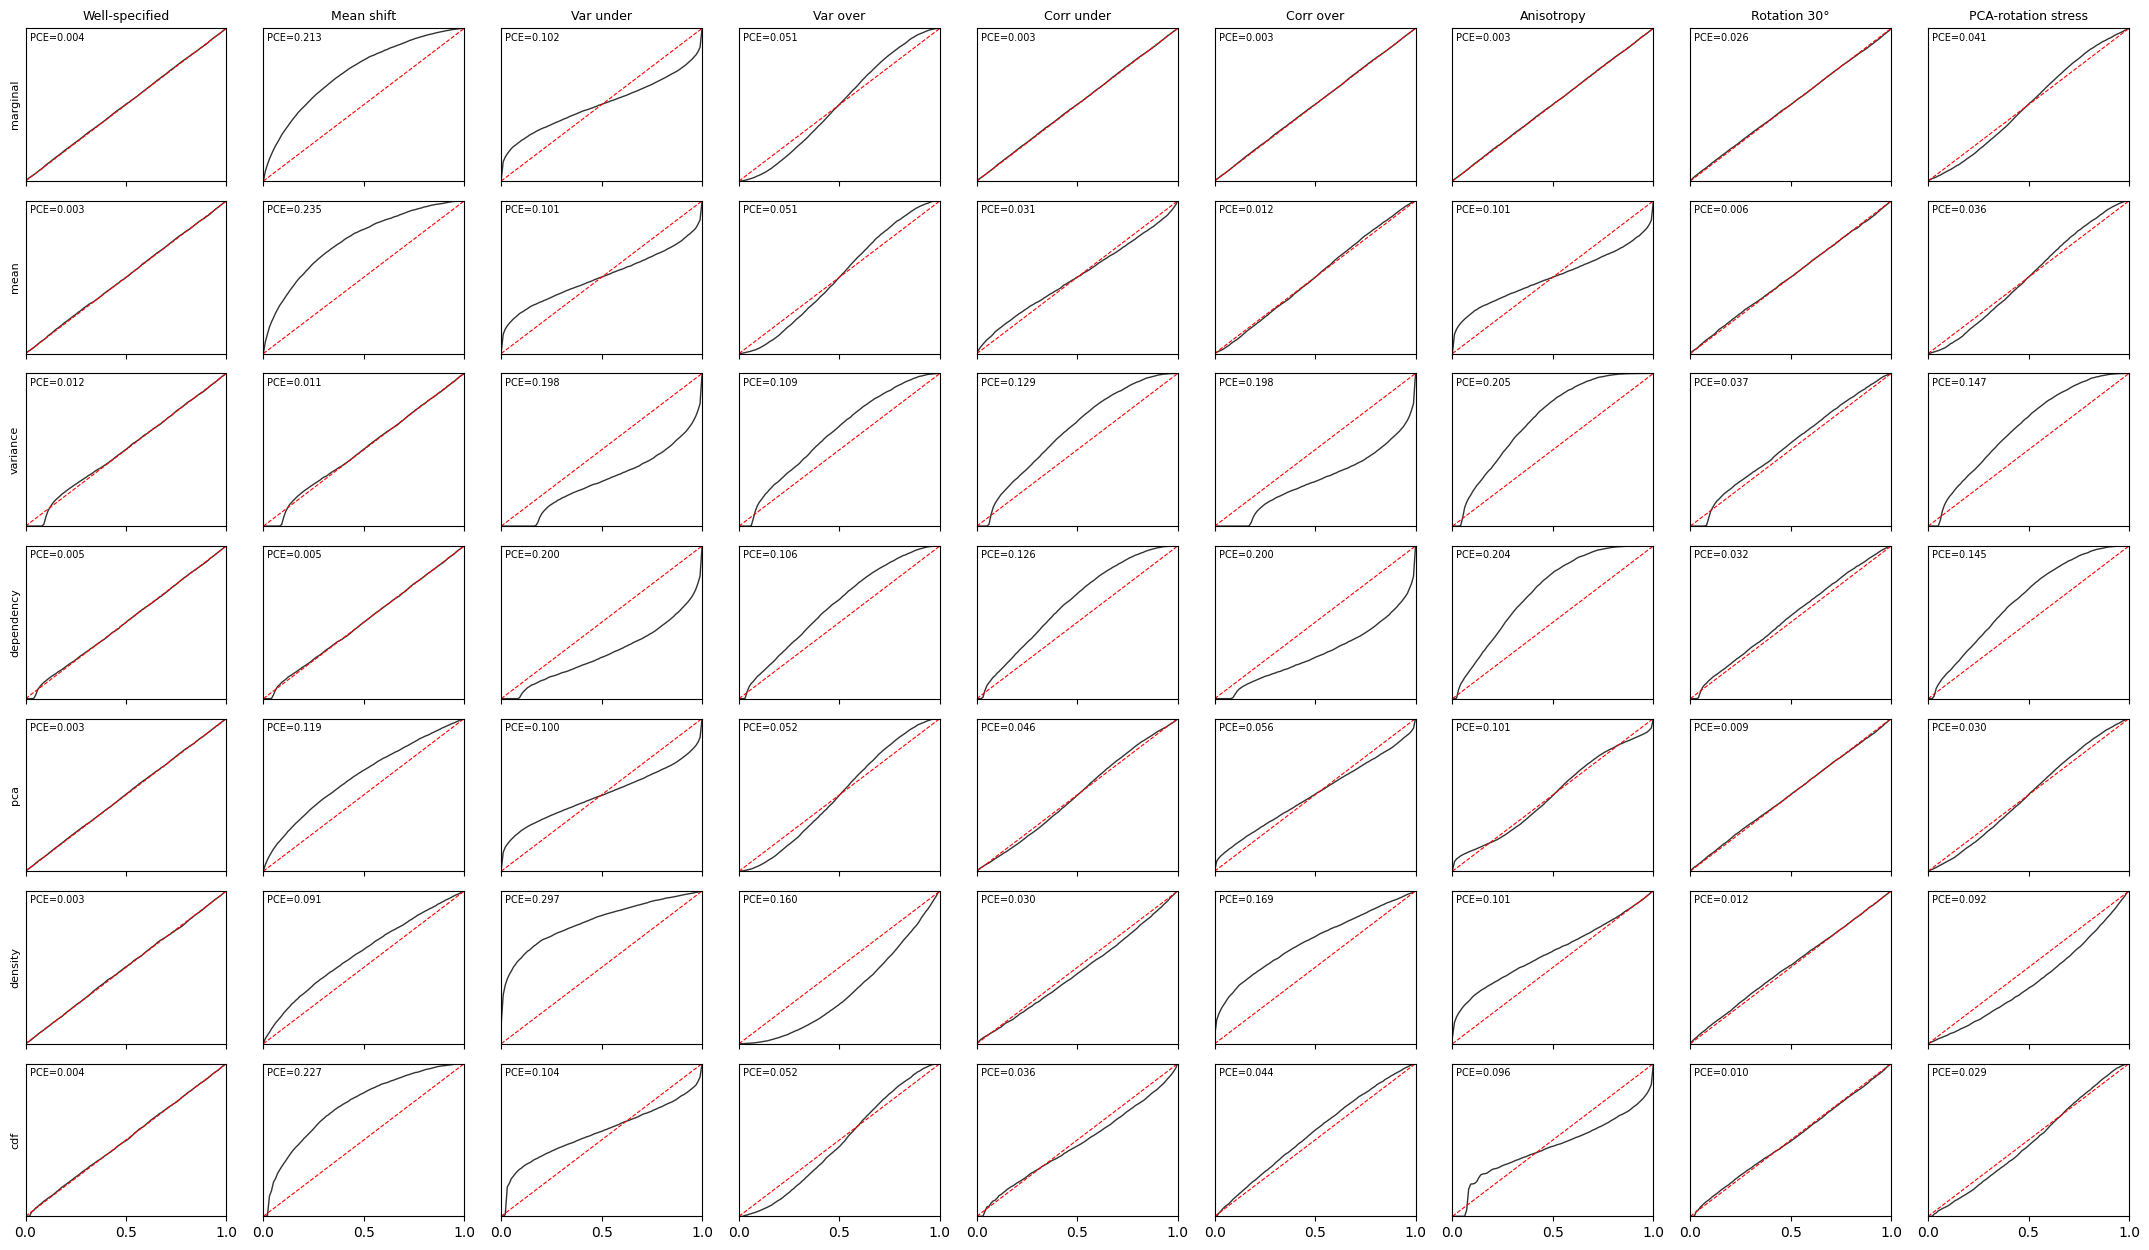

In [ ]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_batch_mvn(mean, cov, n):
    mean = torch.tensor(mean, dtype=torch.float32, device=device).expand(n, -1)
    cov = torch.tensor(cov, dtype=torch.float32, device=device).expand(n, -1, -1)
    return torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)

N = 5000
mu_true = np.zeros(D)
cov_true = exp_decay_cov(D, sigma2_true, tau_true)

dist_true = torch.distributions.MultivariateNormal(
    torch.tensor(mu_true, dtype=torch.float32, device=device),
    covariance_matrix=torch.tensor(cov_true, dtype=torch.float32, device=device),
)
y = dist_true.sample((N,))

mean_shift = np.full(D, 0.8)
cov_var_under = exp_decay_cov(D, sigma2_true * 0.5, tau_true)
cov_var_over = exp_decay_cov(D, sigma2_true * 1.4, tau_true)
cov_corr_under = exp_decay_cov(D, sigma2_true, tau_true * 0.3)
cov_corr_over = exp_decay_cov(D, sigma2_true, tau_true * 3.0)

anis_factors = np.ones(D)
anis_factors[:max(1, D//2)] = 2.5
cov_aniso = np.diag(anis_factors) @ cov_true @ np.diag(anis_factors)

cases = [
    ("Well-specified", mu_true, cov_true),
    ("Mean shift", mean_shift, cov_true),
    ("Var under", mu_true, cov_var_under),
    ("Var over", mu_true, cov_var_over),
    ("Corr under", mu_true, cov_corr_under),
    ("Corr over", mu_true, cov_corr_over),
    ("Anisotropy", mu_true, cov_aniso),
]

preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

alphas = np.linspace(0, 1, 100)

def _mean_cdf_and_pce(cdfs, pces):
    cdf_mean = cdfs.mean(dim=0).detach().cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean

fig, axs = plt.subplots(len(preranks), len(cases),
                        figsize=(2.4 * len(cases), 1.8 * len(preranks)),
                        sharex=True, sharey=True)

for j, (name, mu_pred, cov_pred) in enumerate(cases):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N)
    for i, pr in enumerate(preranks):
        pces, cdfs = pce(dist_pred, y, n_samples=1000, prerank=pr, setup="real")
        cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
        ax = axs[i, j]
        ax.plot(alphas, cdf_mean, color="0.2", lw=1)
        ax.plot([0, 1], [0, 1], "r--", lw=0.8)
        if i == 0:
            ax.set_title(name, fontsize=9)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([])
        ax.text(0.02, 0.92, f"PCE={pce_mean:.3f}", transform=ax.transAxes, fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# True data parameters
D = 10
sigma2_true = 1.0
tau_true = 1.0
mu_true = np.zeros(D)


def exp_decay_cov(d, sigma2, tau):
    idx = np.arange(d)
    dist = np.abs(idx[:, None] - idx[None, :])
    return sigma2 * np.exp(-dist / tau)


cov_true = exp_decay_cov(D, sigma2_true, tau_true)

In [4]:
# -------------------------
# User preranks (order = rows)
# -------------------------
prerank_order = ["cdf", "density", "dependency", "marginal", "mean", "pca", "variance"]

# -------------------------
# Rank histogram utilities
# -------------------------
def rank_of_truth(truth_score, ens_scores):
    """
    Randomized rank to handle ties fairly.
    Returns integer rank in [0, M] (M = ensemble size).
    """
    M = len(ens_scores)
    less = np.sum(ens_scores < truth_score)
    equal = np.sum(ens_scores == truth_score)
    # place truth uniformly among equals
    return less + np.random.randint(0, equal + 1)

def make_rank_hist(truth_scores, ens_scores_matrix):
    """
    truth_scores: shape [N]
    ens_scores_matrix: shape [N, M]
    returns ranks: shape [N], each in [0..M]
    """
    N, M = ens_scores_matrix.shape
    ranks = np.empty(N, dtype=int)
    for i in range(N):
        ranks[i] = rank_of_truth(truth_scores[i], ens_scores_matrix[i])
    return ranks

# -------------------------
# Multivariate simulation cases (columns)
# Each case returns (truth, ensemble_members) for one trial
# truth: shape [d]
# ens:   shape [M, d]
# -------------------------
def make_cov(d, rho):
    C = np.full((d, d), rho)
    np.fill_diagonal(C, 1.0)
    return C

def cov_from_angle_d(theta_deg,d,lam1=3.0,lam2=0.6,lam_rest=1.0,plane=(0, 1)):

    i, j = plane
    assert 0 <= i < d and 0 <= j < d and i != j

    # 1) Eigenvalues
    eigvals = np.full(d, lam_rest)
    eigvals[i] = lam1
    eigvals[j] = lam2
    D = np.diag(eigvals)

    # 2) Rotation matrix (identity except 2D plane)
    th = np.deg2rad(theta_deg)
    R = np.eye(d)
    R[i, i] =  np.cos(th)
    R[j, j] =  np.cos(th)
    R[i, j] = -np.sin(th)
    R[j, i] =  np.sin(th)

    # 3) Rotate covariance
    return R @ D @ R.T


def sample_case(case_name, d, M, rng):
    """
    Return one (truth, ens) draw for a named failure mode.
    Ensemble is designed to be wrong in a specific way.
    """
    # "Truth" distribution
    mu_t = np.zeros(d)
    rho_t = 0.6
    cov_t = make_cov(d, rho_t)

    # Start ensemble as correct, then perturb per-case
    mu_f = mu_t.copy()
    cov_f = cov_t.copy()

    if case_name == "Well-calibrated":
        pass

    elif case_name == "Mean bias":
        mu_f = mu_t + 0.8  # shift all dims

    elif case_name == "Under-dispersed":
        cov_f = 0.6 * cov_t  # too little spread

    elif case_name == "Over-dispersed":
        cov_f = 1.6 * cov_t  # too much spread

    elif case_name == "Wrong correlation":
        # keep marginals ~ right, but correlation structure wrong
        cov_f = make_cov(d, rho=0.05)

    elif case_name == "Anisotropy (PCA)":
        # Rotate + stretch one direction (PCA mismatch)
        # truth is isotropic-ish; forecast has a strong first PC
        # U = np.eye(d)
        # U[0, 0] = 2.5  # inflate variance in first axis
        # cov_f = U @ cov_t @ U

        cov_f = cov_from_angle_d(70.0)

    else:
        raise ValueError(f"Unknown case: {case_name}")

    # Draw truth and ensemble
    truth = rng.multivariate_normal(mu_t, cov_t)
    ens = rng.multivariate_normal(mu_f, cov_f, size=M)
    return truth, ens, (mu_f, cov_f)  # also return forecast params for density-type scores

# -------------------------
# Prerank score functions: map vector -> scalar score
# These are "proxy" preranks to illustrate behavior.
# -------------------------
def score_mean(x):
    return np.mean(x)

def score_variance(x):
    return np.var(x)

def score_marginal(x):
    # "marginal" proxy: sum of absolute deviations (sensitive to 1D distribution mismatches)
    return np.sum(np.abs(x))

def score_dependency(x):
    # "dependency" proxy: sum of pairwise products (sensitive to correlation sign/strength)
    # (Not a full dependency metric, but works as a teaching example.)
    s = 0.0
    for i in range(len(x)):
        for j in range(i + 1, len(x)):
            s += x[i] * x[j]
    return s

def score_pca(x):
    # "pca" proxy: energy in the first coordinate relative to total (anisotropy indicator)
    denom = np.sum(x**2) + 1e-12
    return (x[0] ** 2) / denom

def score_mahalanobis_cdf(x, mu_f, cov_f):
    # "cdf" proxy: Mahalanobis distance (monotone with Gaussian CDF radius)
    # We avoid scipy; use squared Mahalanobis distance as score.
    dx = x - mu_f
    inv = np.linalg.pinv(cov_f)
    return float(dx.T @ inv @ dx)

def score_density(x, mu_f, cov_f):
    # "density" proxy: Gaussian negative log-likelihood (up to a constant)
    # nll = 0.5*(logdet + mahal) ; constants omitted
    dx = x - mu_f
    inv = np.linalg.pinv(cov_f)
    mahal = float(dx.T @ inv @ dx)
    sign, logdet = np.linalg.slogdet(cov_f + 1e-9 * np.eye(len(x)))
    if sign <= 0:
        logdet = np.log(np.maximum(np.linalg.det(cov_f), 1e-12))
    return 0.5 * (logdet + mahal)

PRERANK_FUNS = {
    "mean":      lambda x, ctx: score_mean(x),
    "variance":  lambda x, ctx: score_variance(x),
    "marginal":  lambda x, ctx: score_marginal(x),
    "dependency":lambda x, ctx: score_dependency(x),
    "pca":       lambda x, ctx: score_pca(x),
    "cdf":       lambda x, ctx: score_mahalanobis_cdf(x, ctx["mu_f"], ctx["cov_f"]),
    "density":   lambda x, ctx: score_density(x, ctx["mu_f"], ctx["cov_f"]),
}

# -------------------------
# Main: generate rank hist grid
# Rows = preranks, Cols = cases
# -------------------------
def plot_prerank_rankhist_grid(
    preranks,
    cases,
    d=4,
    M=20,
    N=4000,
    seed=0,
):
    rng = np.random.default_rng(seed)

    # Precompute ranks for each (prerank, case)
    all_ranks = {p: {} for p in preranks}

    for case in cases:
        # Collect N trials of truth and ensemble, then scores
        truth_scores = {p: np.empty(N) for p in preranks}
        ens_scores   = {p: np.empty((N, M)) for p in preranks}

        for i in range(N):
            truth, ens, (mu_f, cov_f) = sample_case(case, d=d, M=M, rng=rng)
            ctx = {"mu_f": mu_f, "cov_f": cov_f}

            for p in preranks:
                f = PRERANK_FUNS[p]
                truth_scores[p][i] = f(truth, ctx)
                ens_scores[p][i, :] = np.array([f(e, ctx) for e in ens])

        for p in preranks:
            all_ranks[p][case] = make_rank_hist(truth_scores[p], ens_scores[p])

    # Plot
    nrows = len(preranks)
    ncols = len(cases)

    fig_w = 2.2 * ncols
    fig_h = 1.6 * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True, sharey=True)

    if nrows == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes[:, np.newaxis]

    bins = np.arange(M + 2) - 0.5  # bins for ranks 0..M
    uniform = N / (M + 1)

    for r, p in enumerate(preranks):
        for c, case in enumerate(cases):
            ax = axes[r, c]
            ranks = all_ranks[p][case]

            ax.hist(ranks, bins=bins, edgecolor="none")
            ax.axhline(uniform, linestyle="--", linewidth=1)  # uniform reference

            # cosmetics
            ax.set_xlim(-0.5, M + 0.5)
            ax.tick_params(axis="both", which="both", length=2)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)

            if r == 0:
                ax.set_title(case, fontsize=9, pad=4)
            if c == 0:
                ax.set_ylabel(p, fontsize=9)

    # bottom labels
    for ax in axes[-1, :]:
        ax.set_xlabel("Rank", fontsize=9)

    fig.suptitle("Rank histograms by prerank", fontsize=11, y=1.02)
    fig.tight_layout()
    plt.show()

# -------------------------
# Choose cases (columns): each highlights a different failure mode
# -------------------------
cases = [
    "Well-calibrated",
    "Mean bias",
    "Under-dispersed",
    "Over-dispersed",
    "Wrong correlation",
    "Anisotropy (PCA)",
]

plot_prerank_rankhist_grid(
    preranks=prerank_order,
    cases=cases,
    d=4,      # dimension of multivariate variable
    M=20,     # ensemble size
    N=4000,   # number of trials (increase for smoother histograms)
    seed=1,
)

TypeError: cov_from_angle_d() missing 1 required positional argument: 'd'

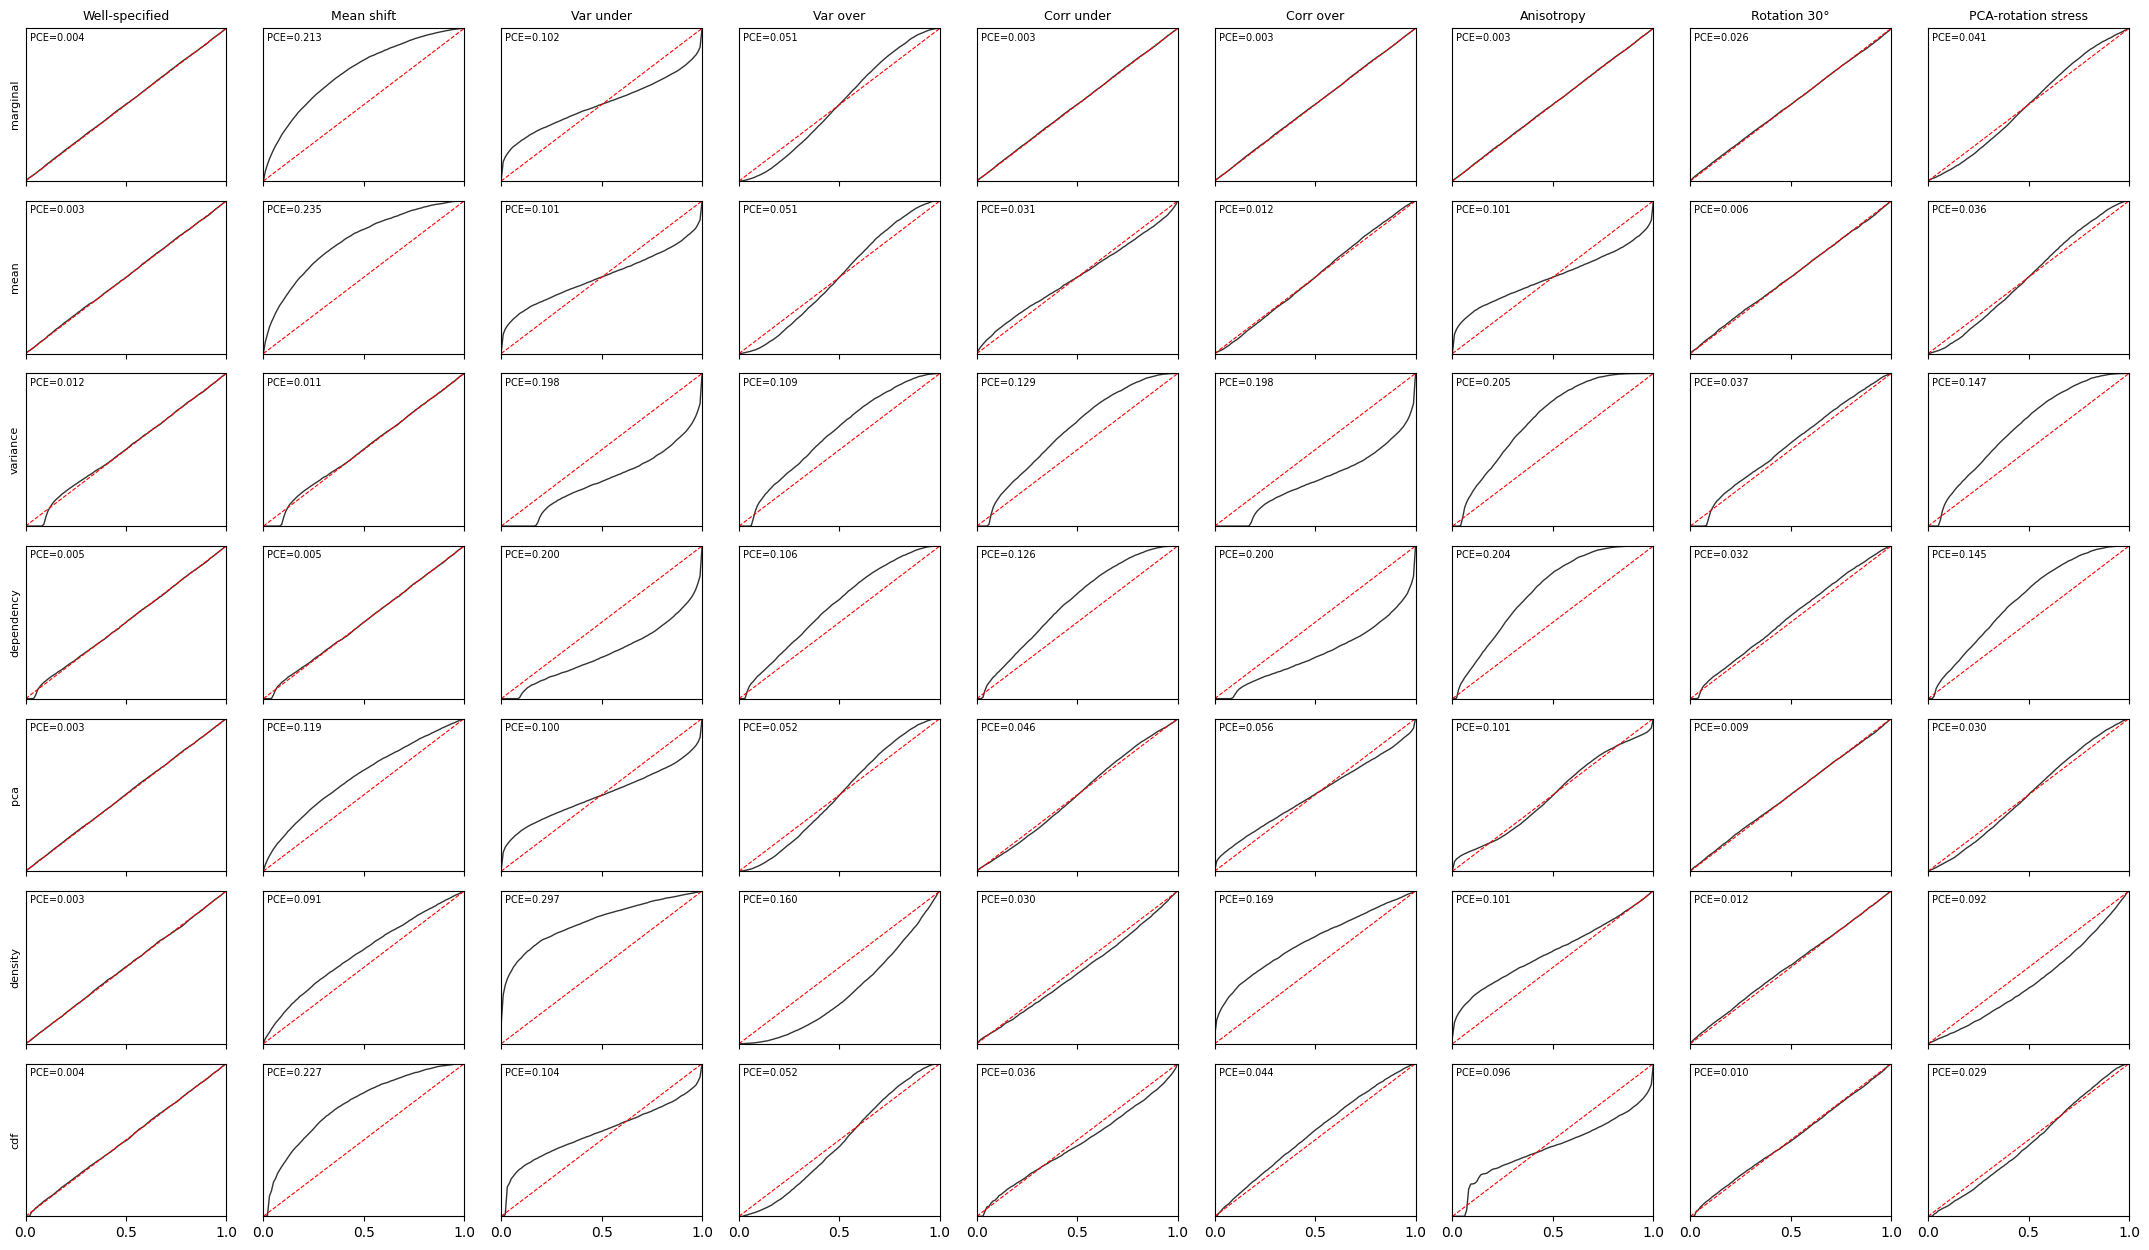

In [12]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_batch_mvn(mean, cov, n):
    mean = torch.tensor(mean, dtype=torch.float32, device=device).expand(n, -1)
    cov = torch.tensor(cov, dtype=torch.float32, device=device).expand(n, -1, -1)
    return torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)

N = 5000
mu_true = np.zeros(D)
cov_true = exp_decay_cov(D, sigma2_true, tau_true)

dist_true = torch.distributions.MultivariateNormal(
    torch.tensor(mu_true, dtype=torch.float32, device=device),
    covariance_matrix=torch.tensor(cov_true, dtype=torch.float32, device=device),
)
y = dist_true.sample((N,))

mean_shift = np.full(D, 0.8)
cov_var_under = exp_decay_cov(D, sigma2_true * 0.5, tau_true)
cov_var_over = exp_decay_cov(D, sigma2_true * 1.4, tau_true)
cov_corr_under = exp_decay_cov(D, sigma2_true, tau_true * 0.3)
cov_corr_over = exp_decay_cov(D, sigma2_true, tau_true * 3.0)

anis_factors = np.ones(D)
anis_factors[:max(1, D//2)] = 2.5
cov_aniso = np.diag(anis_factors) @ cov_true @ np.diag(anis_factors)

cases = [
    ("Well-specified", mu_true, cov_true),
    ("Mean shift", mean_shift, cov_true),
    ("Var under", mu_true, cov_var_under),
    ("Var over", mu_true, cov_var_over),
    ("Corr under", mu_true, cov_corr_under),
    ("Corr over", mu_true, cov_corr_over),
    ("Anisotropy", mu_true, cov_aniso),
]

preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

alphas = np.linspace(0, 1, 100)

def _mean_cdf_and_pce(cdfs, pces):
    cdf_mean = cdfs.mean(dim=0).detach().cpu().numpy()
    pce_mean = float(pces.mean())
    return cdf_mean, pce_mean

fig, axs = plt.subplots(len(preranks), len(cases),
                        figsize=(2.4 * len(cases), 1.8 * len(preranks)),
                        sharex=True, sharey=True)

for j, (name, mu_pred, cov_pred) in enumerate(cases):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N)
    for i, pr in enumerate(preranks):
        pces, cdfs = pce(dist_pred, y, n_samples=1000, prerank=pr, setup="real")
        cdf_mean, pce_mean = _mean_cdf_and_pce(cdfs, pces)
        ax = axs[i, j]
        ax.plot(alphas, cdf_mean, color="0.2", lw=1)
        ax.plot([0, 1], [0, 1], "r--", lw=0.8)
        if i == 0:
            ax.set_title(name, fontsize=9)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([])
        ax.text(0.02, 0.92, f"PCE={pce_mean:.3f}", transform=ax.transAxes, fontsize=7)

plt.tight_layout()
plt.show()

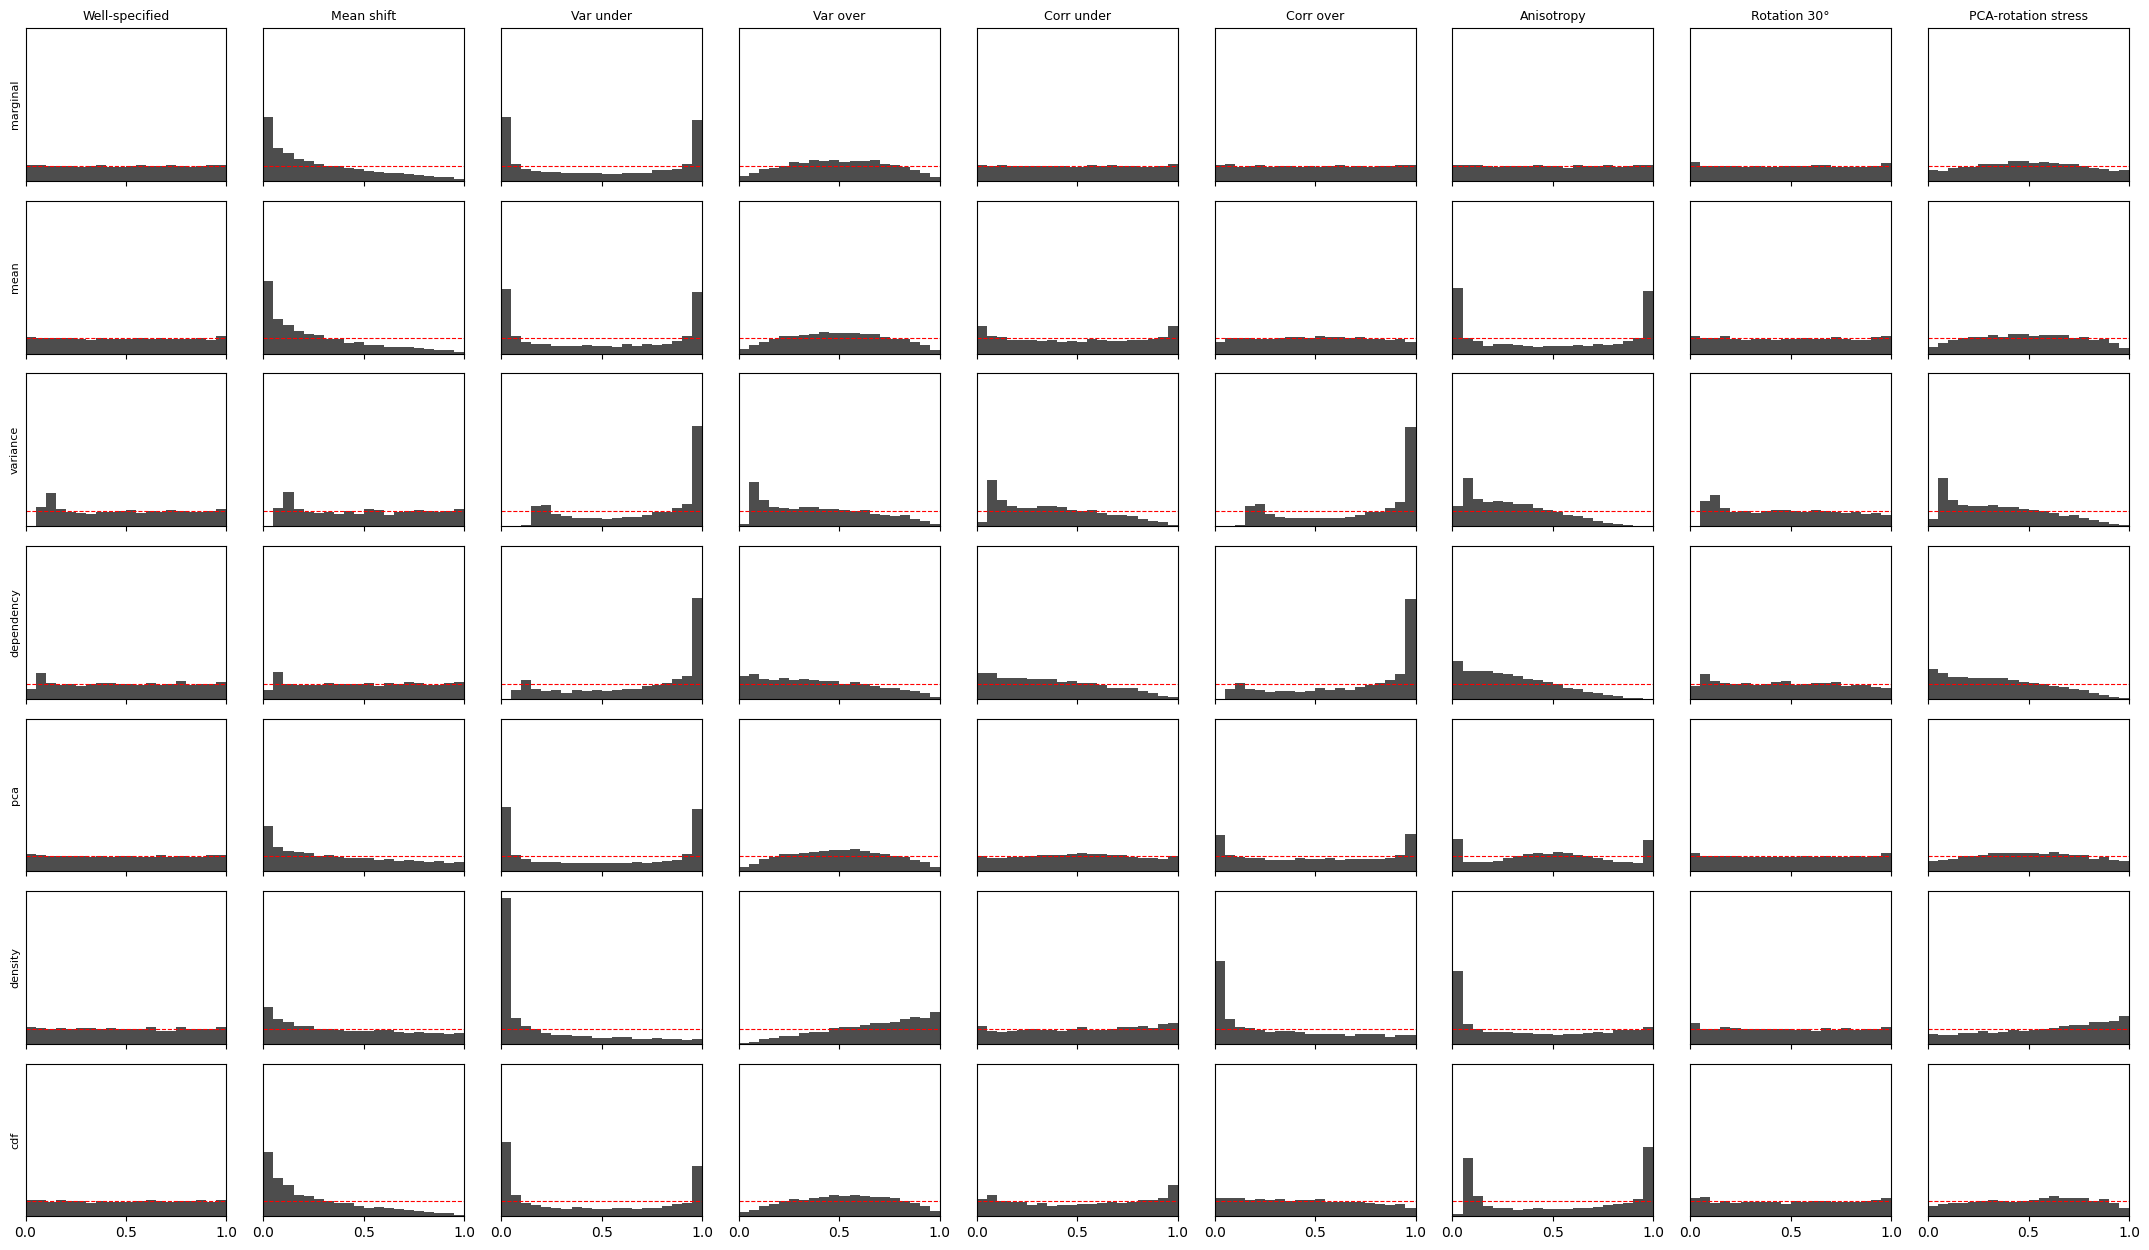

In [13]:
# PIT histograms for the same synthetic cases

def pit_vals(dist_pred_batch, y, prerank, n_samples=1000):
    pits, _ = calculate_PIT(dist_pred_batch, y, n_samples=n_samples, prerank=prerank, setup="real")
    return pits.squeeze(-1).reshape(-1).detach().cpu().numpy()

fig, axs = plt.subplots(len(preranks), len(cases),
                        figsize=(2.4 * len(cases), 1.8 * len(preranks)),
                        sharex=True, sharey=True)

for j, (name, mu_pred, cov_pred) in enumerate(cases):
    dist_pred = make_batch_mvn(mu_pred, cov_pred, N)
    for i, pr in enumerate(preranks):
        pits = pit_vals(dist_pred, y, pr, n_samples=100)
        ax = axs[i, j]
        ax.hist(pits, bins=20, range=(0, 1), density=True, color="0.3")
        ax.plot([0, 1], [1, 1], "r--", lw=0.8)
        if i == 0:
            ax.set_title(name, fontsize=9)
        if j == 0:
            ax.set_ylabel(pr, fontsize=8)
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([])

plt.tight_layout()
plt.show()